In [1]:
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.5.1+cu121
CUDA Available: True
CUDA Version: 12.1
GPU Name: NVIDIA RTX A4000


In [2]:
# ============================================================
# Step 1 — Environment, Imports, Reproducibility, and Runtime Setup
# Target Architecture: PSPNet (ResNet101 Dilated + Pyramid Pooling Module)
# Target Dataset: KITTI Semantic Segmentation
# Optimization Mode: VRAM-Armored Mixed Precision Fine-Tuning
# ============================================================

import os
import cv2
import gc
import math
import glob
import time
import random
import warnings
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Strict CUDA memory behavior to prevent fragmentation on 16GB VRAM
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models

# Schedulers & Data Loading
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR, PolynomialLR
from torch.utils.data import Dataset, DataLoader

# VRAM Optimization Tools (AMP)
from torch.amp import GradScaler, autocast

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm

# --------------------------------------------------
# Cleanup and Warning Control
# --------------------------------------------------
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

warnings.filterwarnings("ignore", category=UserWarning)

# --------------------------------------------------
# Reproducibility Setup
# --------------------------------------------------
SEED = 42

def set_seed(seed: int = 42, deterministic: bool = False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        try:
            torch.use_deterministic_algorithms(True)
        except Exception:
            pass
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

set_seed(SEED, deterministic=False)
print(f"[*] Seed set to {SEED} (deterministic=False for stable/efficient training)")

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# --------------------------------------------------
# Matplotlib & Seaborn Styling Setup
# --------------------------------------------------
%matplotlib inline
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")
sns.set_context("talk", font_scale=0.9)

# --------------------------------------------------
# Device & Engine Configuration
# --------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Using Device: {DEVICE}")

if torch.cuda.is_available():
    print(f"    GPU Model: {torch.cuda.get_device_name(0)}")
    print(f"    CUDA Toolchain Version: {torch.version.cuda}")
    print(f"    Total Available GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    try:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        print("    TF32 matrix operations enabled successfully.")
    except Exception as e:
        print(f"    TF32 configuration skipped: {e}")

# --------------------------------------------------
# Strategy Variables for PSPNet
# --------------------------------------------------
# The PSPNet paper mandates an effective batch size of 16[cite: 1].
# If physical memory is capped, we rely heavily on gradient accumulation.
PHYSICAL_BATCH_SIZE = 2
GRAD_ACCUM_STEPS = 8  # 2 * 8 = 16 Effective Batch Size
USE_AMP = torch.cuda.is_available()
scaler = GradScaler("cuda" if torch.cuda.is_available() else "cpu", enabled=USE_AMP)

print(f"[*] Mixed Precision Training Enabled: {USE_AMP}")
print(f"[*] Targeting Effective Batch Size: {PHYSICAL_BATCH_SIZE * GRAD_ACCUM_STEPS}")

# --------------------------------------------------
# CENTRALIZED DIRECTORY & PATH MAPPING
# --------------------------------------------------
KITTI_ROOT = Path("/home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/KITTI/training")
IMG_ROOT = KITTI_ROOT / "image_2"
MASK_ROOT = KITTI_ROOT / "semantic"

FINAL_SAVE_DIR = Path("/home/hrusikesh-nishank/Pictures/PSPNet_kitti/Results_Export_PSPNet_kitti") 
QUAL_VIS_DIR = Path("/home/hrusikesh-nishank/Pictures/PSPNet_kitti/training_visuals_PSPNet_kitti")

CHECKPOINT_DIR = FINAL_SAVE_DIR / "progressive_checkpoints_PSPNet_kitti"
PLOTS_DIR = FINAL_SAVE_DIR / "training_plots_PSPNet_kitti"
LOGS_DIR = FINAL_SAVE_DIR / "training_logs_PSPNet_kitti"
METRICS_DIR = FINAL_SAVE_DIR / "training_metrics_PSPNet_kitti"

for d in [CHECKPOINT_DIR, PLOTS_DIR, LOGS_DIR, METRICS_DIR, FINAL_SAVE_DIR, QUAL_VIS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Model Specifications
# --------------------------------------------------
MODEL_NAME = "ResNet101_Dilated" 
MODEL_ALIAS = "PSPNet (ResNet101 + Pyramid Pooling Module + Deep Supervision)"

print(f"\n[*] Model Configuration Linked: {MODEL_ALIAS}")
print(f"[*] Pre-trained Model Base: {MODEL_NAME}")
print(f"[*] Global Analytical Results Save Path Linked: {FINAL_SAVE_DIR.resolve()}")

# --------------------------------------------------
# Runtime Performance Containers & Checkpoint Manager
# --------------------------------------------------
HISTORY_FILE = LOGS_DIR / "training_history.csv"

# Pre-initialized with ALL exhaustive metric keys
history = {
    "epoch": [],
    "phase": [],
    "train_total_loss": [],
    "train_main_loss": [],       # Tracked separately for PSPNet
    "train_aux_loss": [],        # Deep supervision auxiliary loss
    "train_miou": [],    
    "train_macc": [],    
    "train_aacc": [],    
    "val_total_loss": [],
    "val_miou": [],
    "val_macc": [],
    "val_aacc": [],
    "learning_rate": [],
    "epoch_time_sec": [],
    "total_training_time_str": [],
    
    "train_Precision_Macro": [],
    "train_Recall_Macro": [],
    "train_F1_Macro": [],
    "train_Precision_Micro": [],
    "train_Recall_Micro": [],
    "train_F1_Micro": [],
    
    "val_Precision_Macro": [],
    "val_Recall_Macro": [],
    "val_F1_Macro": [],
    "val_Precision_Micro": [],
    "val_Recall_Micro": [],
    "val_F1_Micro": []
}

best_record = {
    "epoch": -1,
    "best_miou": -1.0,
    "best_path": str(CHECKPOINT_DIR / "model_best_pspnet_kitti.pth"),
    "latest_path": str(CHECKPOINT_DIR / "model_latest_pspnet_kitti.pth")
}

def save_checkpoint(epoch, model, optimizer, scaler, scheduler, history_dict, total_time, is_best=False):
    """
    Saves dual checkpoints and directly embeds the full history dictionary.
    Also exports the dictionary to CSV for external plotting immunity against power failure.
    """
    state = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
        'history': history_dict,
        'total_training_time': total_time,
        'best_record': best_record
    }
    
    # 1. Update CSV securely
    pd.DataFrame(history_dict).to_csv(HISTORY_FILE, index=False)
    
    # 2. Always overwrite the latest state
    torch.save(state, best_record['latest_path'])
    
    # 3. Save best state if flagged
    if is_best:
        torch.save(state, best_record['best_path'])
        print(f"\n[+] New Best Model Saved! Val mIoU: {best_record['best_miou']:.2f}% | Epoch: {epoch}")

print("\n[*] Metrics tracking layers constructed. Global paths centralized. Checkpoint Manager ready. Step 1 sequence completed.")

[*] Seed set to 42 (deterministic=False for stable/efficient training)
[*] Using Device: cuda
    GPU Model: NVIDIA RTX A4000
    CUDA Toolchain Version: 12.1
    Total Available GPU Memory: 15.73 GB
    TF32 matrix operations enabled successfully.
[*] Mixed Precision Training Enabled: True
[*] Targeting Effective Batch Size: 16

[*] Model Configuration Linked: PSPNet (ResNet101 + Pyramid Pooling Module + Deep Supervision)
[*] Pre-trained Model Base: ResNet101_Dilated
[*] Global Analytical Results Save Path Linked: /home/hrusikesh-nishank/Pictures/PSPNet_kitti/Results_Export_PSPNet_kitti

[*] Metrics tracking layers constructed. Global paths centralized. Checkpoint Manager ready. Step 1 sequence completed.


In [3]:
# ============================================================
# STEP 2: HYPERPARAMETERS, LABEL ENCODING, VISUALIZATION
# Target Architecture: PSPNet (ResNet101 Dilated + Pyramid Pooling Module)
# Target Dataset: KITTI Semantic Segmentation
# Optimization: 120 Epochs, SGD, Poly LR, 713x713 Crops
# ============================================================

import matplotlib.ticker as mtick 
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path

print(f"[*] Image root inherited: {IMG_ROOT}")
print(f"[*] Mask root inherited : {MASK_ROOT}")
print(f"[*] Visualizations target: {QUAL_VIS_DIR.resolve()}")
print(f"[*] Final export target: {FINAL_SAVE_DIR.resolve()}")

# ------------------------------------------------------------
# CORE TASK SETTINGS (KITTI uses Cityscapes 19-Class Standard)
# ------------------------------------------------------------
CLASSES = 19
IGNORE_INDEX = 255
USE_LABEL_TRAINIDS = True

CLASS_NAMES = [
    "Road", "Sidewalk", "Building", "Wall", "Fence", "Pole",
    "Traffic Light", "Traffic Sign", "Vegetation", "Terrain", "Sky",
    "Person", "Rider", "Car", "Truck", "Bus", "Train", "Motorcycle", "Bicycle"
]

# Standard KITTI/Cityscapes RGB Color Palette
KITTI_PALETTE = np.array([
    [128, 64, 128],   # Road
    [244, 35, 232],   # Sidewalk
    [70, 70, 70],     # Building
    [102, 102, 156],  # Wall
    [190, 153, 153],  # Fence
    [153, 153, 153],  # Pole
    [250, 170, 30],   # Traffic Light
    [220, 220, 0],    # Traffic Sign
    [107, 142, 35],   # Vegetation
    [152, 251, 152],  # Terrain
    [70, 130, 180],   # Sky
    [220, 20, 60],    # Person
    [255, 0, 0],      # Rider
    [0, 0, 142],      # Car
    [0, 0, 70],       # Truck
    [0, 60, 100],     # Bus
    [0, 80, 100],     # Train
    [0, 0, 230],      # Motorcycle
    [119, 11, 32]     # Bicycle
], dtype=np.uint8)

# ------------------------------------------------------------
# IMAGE GEOMETRY & CROP SIZE (Paper Standard)
# ------------------------------------------------------------
# Strict 713x713 cropping as per official PSPNet training
IMG_H = 713
IMG_W = 713

# KITTI native resolution is approx ~375x1242. 
# Padding to nearest multiples of 32 for valid convolutions.
VAL_IMG_H = 384  
VAL_IMG_W = 1248  

# ------------------------------------------------------------
# TRAINING EPOCHS
# ------------------------------------------------------------
EPOCHS = 120
USE_EARLY_STOPPING = False  

# Deep Supervision Auxiliary Loss Weight
AUX_WEIGHT = 0.4  

# ------------------------------------------------------------
# OPTIMIZATION SCHEDULE (SGD + Poly Policy as specified in PSPNet paper)
# ------------------------------------------------------------
BASE_LR = 0.01            # PSPNet Paper default
MOMENTUM = 0.9            # Momentum set to 0.9
WEIGHT_DECAY = 0.0001     # PSPNet Paper weight decay
WARMUP_EPOCHS = 0         # Standard Poly LR policy starting at Base LR
LR_POWER = 0.9            # Poly policy exponent (1 - iter/max_iter)^0.9

print("\n--- PSPNet ResNet101 Optimization Schedule (Strict Paper Replication) ---")
print(f"Target Total Epochs     : {EPOCHS} ")
print(f"Base Learning Rate      : {BASE_LR}")
print(f"Momentum                : {MOMENTUM}")
print(f"Weight Decay            : {WEIGHT_DECAY}")
print(f"Poly LR Power           : {LR_POWER}")
print(f"Auxiliary Loss Weight   : {AUX_WEIGHT}")
print(f"Crop Size               : {IMG_H}x{IMG_W}")

# ------------------------------------------------------------
# VALIDATION / INFERENCE SETTINGS
# ------------------------------------------------------------
USE_SLIDING_WINDOW_VAL = True
VAL_WINDOW_SIZE = (713, 713)
VAL_WINDOW_STRIDE = (512, 512)   
USE_FLIP_TTA = True              

# ------------------------------------------------------------
# 34 -> 19 LABEL MAPPING & ENCODING (KITTI / Cityscapes Specific)
# ------------------------------------------------------------
mapping_34_to_19 = {
    0: 255, 1: 255, 2: 255, 3: 255, 4: 255, 5: 255, 6: 255,
    7: 0, 8: 1, 9: 255, 10: 255, 11: 2, 12: 3, 13: 4,
    14: 255, 15: 255, 16: 255, 17: 5, 18: 255, 19: 6, 20: 7,
    21: 8, 22: 9, 23: 10, 24: 11, 25: 12, 26: 13, 27: 14,
    28: 15, 29: 255, 30: 255, 31: 16, 32: 17, 33: 18, -1: 255
}

LABEL_LUT = np.full(256, IGNORE_INDEX, dtype=np.uint8)
for k, v in mapping_34_to_19.items():
    if 0 <= k <= 255:
        LABEL_LUT[k] = v

def encode_mask(mask: np.ndarray) -> np.ndarray:
    uniq = np.unique(mask)
    if uniq.max() <= 255 and np.all(np.isin(uniq, list(range(CLASSES)) + [IGNORE_INDEX])):
        return mask.astype(np.uint8)
    encoded = LABEL_LUT[mask.clip(0, 255)]
    return encoded.astype(np.uint8)

def decode_segmap(segmentation_map: np.ndarray) -> np.ndarray:
    h, w = segmentation_map.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    valid_mask = (segmentation_map >= 0) & (segmentation_map < CLASSES)
    for label, color in enumerate(KITTI_PALETTE):
        rgb[segmentation_map == label] = color
    rgb[~valid_mask] = np.array([0, 0, 0], dtype=np.uint8)
    return rgb

# ------------------------------------------------------------
# PUBLICATION-READY EVALUATION CURVES (Strictly % Formatted)
# ------------------------------------------------------------
def plot_training_curves(history_dict, save_path=FINAL_SAVE_DIR):
    keys_to_extract = ['epoch', 'train_total_loss', 'val_total_loss', 'train_miou', 'val_miou', 'train_F1_Macro', 'val_F1_Macro']
    safe_dict = {}
    
    target_len = len(history_dict.get('epoch', []))
    if target_len == 0: return

    for k in keys_to_extract:
        if k in history_dict:
            col = history_dict[k]
            if len(col) > target_len:
                safe_dict[k] = col[:target_len]
            elif len(col) < target_len:
                safe_dict[k] = col + [np.nan] * (target_len - len(col))
            else:
                safe_dict[k] = col
        else:
            safe_dict[k] = [np.nan] * target_len

    df = pd.DataFrame(safe_dict)

    interval_df = df[(df['epoch'] % 5 == 0) | (df['epoch'] == df['epoch'].max())].copy()
    
    if interval_df.empty: return
    epochs_filtered = interval_df['epoch'].values

    sns.set_theme(style="darkgrid")
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))

    axes[0].plot(epochs_filtered, interval_df["train_total_loss"], marker='o', label='Train Loss', color='blue', linewidth=2)
    if not interval_df["val_total_loss"].isna().all():
        axes[0].plot(epochs_filtered, interval_df["val_total_loss"], marker='s', label='Validation Loss', color='red', linewidth=2)
    axes[0].set_title('Loss Progress', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].legend(fontsize=12)

    axes[1].plot(epochs_filtered, interval_df["train_miou"], marker='o', label='Train mIoU', color='green', linewidth=2)
    if not interval_df["val_miou"].isna().all():
        axes[1].plot(epochs_filtered, interval_df["val_miou"], marker='s', label='Validation mIoU', color='orange', linewidth=2)
    axes[1].set_title('mIoU Progress', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('mIoU', fontsize=12)
    axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
    axes[1].legend(fontsize=12)

    axes[2].plot(epochs_filtered, interval_df["train_F1_Macro"], marker='o', label='Train F1 (Macro)', color='purple', linewidth=2)
    if not interval_df["val_F1_Macro"].isna().all():
        axes[2].plot(epochs_filtered, interval_df["val_F1_Macro"], marker='s', label='Validation F1 (Macro)', color='magenta', linewidth=2)
    axes[2].set_title('F1-Score Progress', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('F1 Score', fontsize=12)
    axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
    axes[2].legend(fontsize=12)

    plt.tight_layout()
    
    combined_graph_path = save_path / "presentation_metrics_progress_PSPNet.png"
    plt.savefig(combined_graph_path, dpi=600, bbox_inches="tight")
    plt.close()

# ------------------------------------------------------------
# QUALITATIVE VISUALIZATION (PSPNet Adapted)
# ------------------------------------------------------------
def visualize_results(loader, model, epoch, save_path=QUAL_VIS_DIR, max_images=3):
    save_path = Path(save_path)
    save_path.mkdir(parents=True, exist_ok=True)
    model.eval()

    batch = next(iter(loader))
    images, targets = batch[0], batch[1]
    images = images.to(DEVICE)
    _, _, current_h, current_w = images.shape
    
    with torch.no_grad():
        with torch.autocast(device_type="cuda", enabled=(torch.cuda.is_available() and images.is_cuda)):
            outputs = model(images)
            logits = outputs[0] if isinstance(outputs, tuple) else outputs
            logits_up = F.interpolate(logits, size=(current_h, current_w), mode="bilinear", align_corners=False)
            preds = torch.argmax(logits_up, dim=1).cpu().numpy()

    images_np = images.detach().cpu().numpy()
    targets_np = targets.cpu().numpy()

    n = min(max_images, len(images_np))
    fig, axes = plt.subplots(n, 3, figsize=(15, 5 * n))
    if n == 1: axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        img = np.transpose(images_np[i], (1, 2, 0))
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Input Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(decode_segmap(targets_np[i]))
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(decode_segmap(preds[i]))
        axes[i, 2].set_title(f"PSPNet Prediction (Epoch {epoch})")
        axes[i, 2].axis("off")

    plt.tight_layout()
    out_file = save_path / f"epoch_{epoch:03d}_comparison.png"
    plt.savefig(out_file, dpi=600, bbox_inches="tight")
    plt.close(fig)

def save_visuals_every_10_epochs(epoch, loader, model, save_path=QUAL_VIS_DIR, max_images=3):
    if epoch > 0 and epoch % 10 == 0:
        visualize_results(loader, model, epoch, save_path, max_images)

# ------------------------------------------------------------
# QUICK DATA DISCOVERY
# ------------------------------------------------------------
# Updated to general glob format for KITTI (.png files)
train_imgs = sorted(list(IMG_ROOT.rglob("*.png")))
train_masks = sorted(list(MASK_ROOT.rglob("*.png")))

print(f"[*] Discovered {len(train_imgs)} images and {len(train_masks)} masks.")
print("[*] Step 2 strictly configured for PSPNet Architecture Replication on KITTI.")

[*] Image root inherited: /home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/KITTI/training/image_2
[*] Mask root inherited : /home/hrusikesh-nishank/miniconda3/envs/Segmentation/Datasets/KITTI/training/semantic
[*] Visualizations target: /home/hrusikesh-nishank/Pictures/PSPNet_kitti/training_visuals_PSPNet_kitti
[*] Final export target: /home/hrusikesh-nishank/Pictures/PSPNet_kitti/Results_Export_PSPNet_kitti

--- PSPNet ResNet101 Optimization Schedule (Strict Paper Replication) ---
Target Total Epochs     : 120 
Base Learning Rate      : 0.01
Momentum                : 0.9
Weight Decay            : 0.0001
Poly LR Power           : 0.9
Auxiliary Loss Weight   : 0.4
Crop Size               : 713x713
[*] Discovered 200 images and 200 masks.
[*] Step 2 strictly configured for PSPNet Architecture Replication on KITTI.


In [4]:
# ============================================================
# STEP 3: DATASET AND DATALOADERS (PSPNet Adapted)
# Target Architecture: PSPNet (ResNet101 Dilated + Pyramid Pooling Module)
# Target Dataset: KITTI Semantic Segmentation
# Optimized for: 713x713 Crops, Paper-Exact Augmentations
# ============================================================

import inspect
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os
import random

# Note: All major libraries (torch, cv2, albumentations, numpy), paths, 
# and mapping variables are securely inherited from Steps 1 & 2.

# ------------------------------------------------------------
# DATASET DISCOVERY FOR KITTI
# ------------------------------------------------------------
def get_kitti_pairs(img_dir, mask_dir):
    """
    KITTI Semantic Segmentation has images directly in the image_2/ folder
    and matching masks in the semantic/ folder with identical filenames.
    """
    all_imgs = sorted(list(img_dir.glob("*.png")))
    
    valid_imgs = []
    valid_masks = []
    
    for img_path in all_imgs:
        mask_path = mask_dir / img_path.name
        
        if mask_path.exists():
            valid_imgs.append(img_path)
            valid_masks.append(mask_path)
            
    return valid_imgs, valid_masks

all_img_paths, all_mask_paths = get_kitti_pairs(IMG_ROOT, MASK_ROOT)

if len(all_img_paths) == 0:
    raise FileNotFoundError(f"Could not find valid KITTI image/mask pairs. Checked {IMG_ROOT}")

# KITTI typically does not come with a pre-defined validation split in the training folder (200 images total).
# We generate a deterministic 80/20 train/val split here.
combined_pairs = list(zip(all_img_paths, all_mask_paths))
random.Random(SEED).shuffle(combined_pairs)

split_idx = int(len(combined_pairs) * 0.8)
train_pairs = combined_pairs[:split_idx]
val_pairs = combined_pairs[split_idx:]

train_img_paths, train_mask_paths = zip(*train_pairs) if train_pairs else ([], [])
val_img_paths, val_mask_paths = zip(*val_pairs) if val_pairs else ([], [])

train_img_paths, train_mask_paths = list(train_img_paths), list(train_mask_paths)
val_img_paths, val_mask_paths = list(val_img_paths), list(val_mask_paths)

print(f"\n--- KITTI Dataset Split ---")
print(f"[*] Total image/mask pairs      : {len(all_img_paths)}")
print(f"[*] Training image/mask pairs   : {len(train_img_paths)}")
print(f"[*] Validation image/mask pairs : {len(val_img_paths)}")

# ------------------------------------------------------------
# DATASET
# ------------------------------------------------------------
class KITTIDataset(Dataset):
    def __init__(self, image_paths, mask_paths, split="train", transform=None):
        self.transform = transform
        self.split = split
        self.images = image_paths
        self.masks = mask_paths

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = str(self.images[idx])
        mask_path = str(self.masks[idx])

        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        mask_raw = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask_raw is None:
            raise ValueError(f"Failed to read mask: {mask_path}")
            
        # Inherited directly from Step 2 (uses Cityscapes 19-class mapping)
        mask = encode_mask(mask_raw)

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        if not torch.is_tensor(image):
            image = torch.as_tensor(image).permute(2, 0, 1).float()
        
        if not torch.is_tensor(mask):
            mask = torch.as_tensor(mask, dtype=torch.long)
        else:
            mask = mask.long()

        return image, mask

# ------------------------------------------------------------
# AUGMENTATION HELPERS & TRANSFORMS (Strict Paper Replication)
# ------------------------------------------------------------
def pad_if_needed_tf(min_h, min_w, ignore_index=255):
    sig = inspect.signature(A.PadIfNeeded)
    kwargs = dict(min_height=min_h, min_width=min_w, border_mode=cv2.BORDER_CONSTANT, p=1.0)
    if "fill" in sig.parameters:
        kwargs.update(fill=0, fill_mask=ignore_index)
    else:
        kwargs.update(value=0, mask_value=ignore_index)
    return A.PadIfNeeded(**kwargs)

# The PSPNet paper explicitly states:
# "For data augmentation, we adopt random mirror and random resize between 0.5 and 2 for all datasets"
train_transform = A.Compose([
    A.RandomScale(scale_limit=(-0.5, 1.0), interpolation=cv2.INTER_LINEAR, p=1.0), 
    pad_if_needed_tf(IMG_H, IMG_W, IGNORE_INDEX),
    A.RandomCrop(height=IMG_H, width=IMG_W, p=1.0),
    A.HorizontalFlip(p=0.5), # Random mirror
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(transpose_mask=True),
])

# Validation transform runs at padded native resolution to ensure valid convolutions
val_transform = A.Compose([
    pad_if_needed_tf(VAL_IMG_H, VAL_IMG_W, IGNORE_INDEX),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(transpose_mask=True),
])

# ------------------------------------------------------------
# COLLATE FUNCTION 
# ------------------------------------------------------------
def dense_collate_fn(batch):
    images = torch.stack([item[0] for item in batch], dim=0)
    masks = torch.stack([item[1] for item in batch], dim=0)
    return images, masks

# ------------------------------------------------------------
# INITIALIZATION
# ------------------------------------------------------------

train_dataset = KITTIDataset(
    image_paths=train_img_paths, mask_paths=train_mask_paths, split="train",
    transform=train_transform
)

val_dataset = KITTIDataset(
    image_paths=val_img_paths, mask_paths=val_mask_paths, split="val",
    transform=val_transform
)

NUM_WORKERS = min(4, os.cpu_count() if os.cpu_count() is not None else 2)
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = NUM_WORKERS > 0

print(f"\n--- DataLoader Hardware Configuration ---")
print(f"[*] Num workers     : {NUM_WORKERS}")
print(f"[*] Pin memory      : {PIN_MEMORY}")

train_loader = DataLoader(
    train_dataset, batch_size=PHYSICAL_BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True,
    collate_fn=dense_collate_fn,
    worker_init_fn=seed_worker if "seed_worker" in globals() else None,
    generator=g if "g" in globals() else None,
    persistent_workers=PERSISTENT_WORKERS
)

val_loader = DataLoader(
    val_dataset, batch_size=1, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False,
    collate_fn=dense_collate_fn,
    worker_init_fn=seed_worker if "seed_worker" in globals() else None,
    generator=g if "g" in globals() else None,
    persistent_workers=PERSISTENT_WORKERS
)

# ------------------------------------------------------------
# SANITY CHECKS
# ------------------------------------------------------------
train_batch = next(iter(train_loader))
train_images, train_masks = train_batch

print("\n--- Train Batch Sanity Check ---")
print(f"[*] Images shape    : {train_images.shape} (Targeting {IMG_H}x{IMG_W})")
print(f"[*] Masks shape     : {train_masks.shape}")

val_batch = next(iter(val_loader))
val_images, val_masks = val_batch

assert train_images.shape[-2:] == (IMG_H, IMG_W), f"Expected train crop {IMG_H}x{IMG_W}, got {train_images.shape[-2:]}"

print(f"[*] Val images shape: {val_images.shape} (Padded KITTI Resolution)")
print("\n[*] Step 3 configured successfully and ready to feed the PSPNet model.")


--- KITTI Dataset Split ---
[*] Total image/mask pairs      : 200
[*] Training image/mask pairs   : 160
[*] Validation image/mask pairs : 40

--- DataLoader Hardware Configuration ---
[*] Num workers     : 4
[*] Pin memory      : True

--- Train Batch Sanity Check ---
[*] Images shape    : torch.Size([2, 3, 713, 713]) (Targeting 713x713)
[*] Masks shape     : torch.Size([2, 713, 713])
[*] Val images shape: torch.Size([1, 3, 384, 1248]) (Padded KITTI Resolution)

[*] Step 3 configured successfully and ready to feed the PSPNet model.


In [5]:
# ============================================================
# STEP 4: MODEL, OPTIMIZER, LOSS, MULTI-RATE SCHEDULER
# Target Architecture: PSPNet (ResNet101 Dilated + Pyramid Pooling Module)
# Target Dataset: KITTI Semantic Segmentation
# Optimized for: Standard Cross-Entropy, SGD Optimizer, PolyLR Schedule
# ============================================================

import os
import math
import warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import LambdaLR
import torchvision.models as models
from torchvision.models.resnet import ResNet101_Weights

# ------------------------------------------------------------
# SAFETY CHECKS & INHERITANCE
# ------------------------------------------------------------
if "train_loader" not in globals():
    raise NameError("train_loader is not defined. Please run Step 3 first.")

DEVICE = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
CLASSES = globals().get("CLASSES", 19) # Inherited KITTI/Cityscapes classes
IGNORE_INDEX = globals().get("IGNORE_INDEX", 255)

# Inheriting constraints from Step 2
BASE_LR = globals().get("BASE_LR", 0.01)
MOMENTUM = globals().get("MOMENTUM", 0.9)
WEIGHT_DECAY = globals().get("WEIGHT_DECAY", 0.0001)
LR_POWER = globals().get("LR_POWER", 0.9)
AUX_WEIGHT = globals().get("AUX_WEIGHT", 0.4)
EPOCHS = globals().get("EPOCHS", 120)

# ------------------------------------------------------------
# PSPNET COMPONENTS (Pure PyTorch)
# ------------------------------------------------------------

class PyramidPoolingModule(nn.Module):
    """
    Pyramid Pooling Module as described in the PSPNet paper.
    Fuses features under 4 different scales: 1x1, 2x2, 3x3, and 6x6.
    """
    def __init__(self, in_channels, **kwargs):
        super(PyramidPoolingModule, self).__init__()
        # The paper uses 4 levels, reducing dim to 1/4 of original (in_channels // 4)
        out_channels = in_channels // 4
        
        self.pool1 = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        self.pool2 = nn.Sequential(
            nn.AdaptiveAvgPool2d((2, 2)),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        self.pool3 = nn.Sequential(
            nn.AdaptiveAvgPool2d((3, 3)),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        self.pool4 = nn.Sequential(
            nn.AdaptiveAvgPool2d((6, 6)),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        size = x.shape[-2:]
        # Upsample using bilinear interpolation as per the paper
        feat1 = F.interpolate(self.pool1(x), size=size, mode='bilinear', align_corners=False)
        feat2 = F.interpolate(self.pool2(x), size=size, mode='bilinear', align_corners=False)
        feat3 = F.interpolate(self.pool3(x), size=size, mode='bilinear', align_corners=False)
        feat4 = F.interpolate(self.pool4(x), size=size, mode='bilinear', align_corners=False)
        # Concatenate prior with original feature map
        return torch.cat((x, feat1, feat2, feat3, feat4), dim=1)

class PSPNet(nn.Module):
    """
    Complete Pyramid Scene Parsing Network (ResNet101 Backbone).
    """
    def __init__(self, num_classes=19, use_aux=True):
        super(PSPNet, self).__init__()
        self.use_aux = use_aux
        
        # 1. Load Pretrained ResNet101
        resnet = models.resnet101(weights=ResNet101_Weights.IMAGENET1K_V1)
        
        # 2. Extract standard layers (Down to 1/8 resolution)
        self.layer0 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4
        
        # 3. Apply Dilated Network Strategy 
        for n, m in self.layer3.named_modules():
            if 'conv2' in n:
                m.dilation, m.padding, m.stride = (2, 2), (2, 2), (1, 1)
            elif 'downsample.0' in n:
                m.stride = (1, 1)
        for n, m in self.layer4.named_modules():
            if 'conv2' in n:
                m.dilation, m.padding, m.stride = (4, 4), (4, 4), (1, 1)
            elif 'downsample.0' in n:
                m.stride = (1, 1)
                
        # 4. Auxiliary Branch (Attached after layer 3 / res4b22)
        if self.use_aux:
            self.aux_head = nn.Sequential(
                nn.Conv2d(1024, 256, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(256),
                nn.ReLU(inplace=True),
                nn.Dropout2d(p=0.1),
                nn.Conv2d(256, num_classes, kernel_size=1)
            )

        # 5. Pyramid Pooling Module & Main Classifier
        self.ppm = PyramidPoolingModule(in_channels=2048)
        
        # FIX: The PPM concatenates the original 2048 channels + (4 levels * 512 channels) = 4096 channels
        self.cls_head = nn.Sequential(
            nn.Conv2d(4096, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=0.1),
            nn.Conv2d(512, num_classes, kernel_size=1)
        )

    def forward(self, x):
        input_size = x.shape[-2:]
        
        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        
        # Output auxiliary prediction during training
        if self.training and self.use_aux:
            aux_out = self.aux_head(x)
            
        x = self.layer4(x)
        x = self.ppm(x)
        x = self.cls_head(x)
        
        # Return tuples during training for deep supervision, single output during eval
        if self.training and self.use_aux:
            return x, aux_out
        return x

# ------------------------------------------------------------
# LOAD MODEL
# ------------------------------------------------------------
model = PSPNet(num_classes=CLASSES, use_aux=True).to(DEVICE)
print(f"[*] Loaded fresh PSPNet (ResNet101 Backbone) with Deep Supervision for {CLASSES} classes.")

# ------------------------------------------------------------
# STANDARD CROSS-ENTROPY LOSS (No OHEM for official replication)
# ------------------------------------------------------------
criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

def pspnet_loss(outputs, targets, main_criterion, aux_weight=0.4):
    """
    Handles the dual output of PSPNet during training.
    """
    if isinstance(outputs, tuple):
        main_out, aux_out = outputs
        
        # Interpolate logits to match target size
        main_out = F.interpolate(main_out, size=targets.shape[-2:], mode='bilinear', align_corners=False)
        aux_out = F.interpolate(aux_out, size=targets.shape[-2:], mode='bilinear', align_corners=False)
        
        main_loss = main_criterion(main_out, targets)
        aux_loss = main_criterion(aux_out, targets)
        
        total_loss = main_loss + (aux_weight * aux_loss)
        return total_loss, main_loss, aux_loss
    else:
        # Eval mode only returns one output
        outputs = F.interpolate(outputs, size=targets.shape[-2:], mode='bilinear', align_corners=False)
        return main_criterion(outputs, targets), None, None

# ------------------------------------------------------------
# OPTIMIZER CONFIGURATION (SGD for ResNet backbones)
# ------------------------------------------------------------
def configure_pspnet_optimizer(model):
    """
    Configures SGD Optimizer. 
    Often, segmentation heads are given a 10x learning rate multiplier compared to the pretrained backbone.
    """
    backbone_params = []
    head_params = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if "ppm" in name or "cls_head" in name or "aux_head" in name:
            head_params.append(param)
        else:
            backbone_params.append(param)

    param_groups = [
        {"params": backbone_params, "lr": BASE_LR},
        {"params": head_params, "lr": BASE_LR * 10.0} 
    ]

    return optim.SGD(param_groups, lr=BASE_LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)

# ------------------------------------------------------------
# SCHEDULER: PURE POLYNOMIAL DECAY
# ------------------------------------------------------------
def get_poly_scheduler(optimizer, total_steps, power=0.9):
    """
    Poly learning rate policy: base_lr * (1 - iter/max_iter)^power
    """
    def lr_lambda(current_step: int):
        return (1.0 - current_step / total_steps) ** power
    
    return LambdaLR(optimizer, lr_lambda)

# ------------------------------------------------------------
# SYSTEM INITIALIZATION & EPOCH CALCULATION
# ------------------------------------------------------------
optimizer = configure_pspnet_optimizer(model)

steps_per_epoch = math.ceil(len(train_loader) / globals().get("GRAD_ACCUM_STEPS", 8))
total_update_steps = steps_per_epoch * EPOCHS

scheduler = get_poly_scheduler(optimizer, total_update_steps, power=LR_POWER)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n--- Unified Training Architecture Initialized ---")
print(f"[*] Total parameters     : {total_params:,}")
print(f"[*] Trainable parameters : {trainable_params:,}")
print(f"[*] Optimizer            : SGD (Momentum={MOMENTUM})")
print(f"[*] Effective Steps/Epoch: {steps_per_epoch}")
print(f"[*] Target Epochs        : {EPOCHS}")

[*] Loaded fresh PSPNet (ResNet101 Backbone) with Deep Supervision for 19 classes.

--- Unified Training Architecture Initialized ---
[*] Total parameters     : 67,948,390
[*] Trainable parameters : 67,948,390
[*] Optimizer            : SGD (Momentum=0.9)
[*] Effective Steps/Epoch: 10
[*] Target Epochs        : 120


In [6]:
# ============================================================
# STEP 5: TRAINING LOOP (PSPNet Architecture)
# Target Architecture: PSPNet (ResNet101 Dilated + Pyramid Pooling Module)
# Target Dataset: KITTI
# Optimized for: Deep Supervision, PolyLR, and Multi-Scale TTA Inference
# ============================================================

import os
import gc
import math
import time
from datetime import timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm import tqdm

# ------------------------------------------------------------
# SAFETY CHECKS & PATH INHERITANCE
# ------------------------------------------------------------
required_globals = [
    "model", "train_loader", "val_loader", "optimizer", "scheduler", "criterion", "pspnet_loss",
    "DEVICE", "CLASSES", "IGNORE_INDEX", "GRAD_ACCUM_STEPS", "EPOCHS", 
    "FINAL_SAVE_DIR", "QUAL_VIS_DIR", "scaler", "AUX_WEIGHT"
]
missing = [k for k in required_globals if k not in globals()]
if missing:
    print(f"[*] Warning: Missing globals {missing}. Relying on fallback defaults where possible.")

DEVICE = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
USE_AMP = globals().get("USE_AMP", torch.cuda.is_available())

GRAD_CLIP_NORM = globals().get("GRAD_CLIP_NORM", 1.0) 
MIN_DELTA_MIOU = 0.001
EPOCHS = globals().get("EPOCHS", 120) 
AUX_WEIGHT = globals().get("AUX_WEIGHT", 0.4)
CLASSES = globals().get("CLASSES", 19)

# ------------------------------------------------------------
# TEST-TIME AUGMENTATION (TTA) INFERENCE 
# ------------------------------------------------------------
def multi_scale_tta_inference(model, image, scales=[0.75, 1.0, 1.25], num_classes=19):
    B, C, H, W = image.shape
    final_logits = torch.zeros((B, num_classes, H, W), device=image.device, dtype=torch.float32)
    
    model.eval() # Ensures PSPNet returns a single tensor, not a tuple
    for scale in scales:
        sH, sW = int(H * scale), int(W * scale)
        sH, sW = (sH // 32) * 32, (sW // 32) * 32 
        
        scaled_img = F.interpolate(image, size=(sH, sW), mode='bilinear', align_corners=False)
        
        # Standard Pass
        with torch.no_grad():
            with torch.autocast(device_type="cuda", enabled=USE_AMP):
                logits = model(scaled_img)
                logits_up = F.interpolate(logits, size=(H, W), mode="bilinear", align_corners=False)
                final_logits += logits_up.float()
                
        # Flipped Pass
        flipped_img = torch.flip(scaled_img, dims=[3])
        with torch.no_grad():
            with torch.autocast(device_type="cuda", enabled=USE_AMP):
                flip_logits = model(flipped_img)
                flip_logits_up = F.interpolate(flip_logits, size=(H, W), mode="bilinear", align_corners=False)
                final_logits += torch.flip(flip_logits_up, dims=[3]).float()
                
    return final_logits / (len(scales) * 2)

# ------------------------------------------------------------
# EXHAUSTIVE METRICS CALCULATOR
# ------------------------------------------------------------
def compute_metrics(conf_matrix: np.ndarray):
    tp = np.diag(conf_matrix)
    fp = conf_matrix.sum(axis=0) - tp
    fn = conf_matrix.sum(axis=1) - tp
    
    # Per-class metrics
    precision_class = tp / np.maximum(tp + fp, 1)
    recall_class = tp / np.maximum(tp + fn, 1)
    iou_class = tp / np.maximum(tp + fp + fn, 1)
    f1_class = 2 * (precision_class * recall_class) / np.maximum(precision_class + recall_class, 1e-8)

    # Macro Metrics (Averaged across classes)
    macro_precision = np.nanmean(precision_class)
    macro_recall = np.nanmean(recall_class)
    macro_f1 = np.nanmean(f1_class)
    macro_miou = np.nanmean(iou_class)

    # Micro Metrics (Aggregated globally)
    total_tp, total_fp, total_fn = tp.sum(), fp.sum(), fn.sum()
    micro_precision = total_tp / max(total_tp + total_fp, 1)
    micro_recall = total_tp / max(total_tp + total_fn, 1)
    micro_f1 = 2 * (micro_precision * micro_recall) / max(micro_precision + micro_recall, 1e-8)
    micro_miou = total_tp / max(total_tp + total_fp + total_fn, 1)

    return {
        "mIoU_Macro": float(macro_miou),
        "Precision_Macro": float(macro_precision),
        "Recall_Macro": float(macro_recall),
        "F1_Macro": float(macro_f1),
        "mIoU_Micro": float(micro_miou),
        "Precision_Micro": float(micro_precision),
        "Recall_Micro": float(micro_recall),
        "F1_Micro": float(micro_f1)
    }

def fast_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> np.ndarray:
    idx = num_classes * y_true + y_pred
    return np.bincount(idx, minlength=num_classes * num_classes).reshape(num_classes, num_classes)

def get_lr_snapshot(optimizer):
    lrs = [pg["lr"] for pg in optimizer.param_groups]
    return lrs[0], lrs[1] if len(lrs) > 1 else lrs[0]

# ------------------------------------------------------------
# CRASH RECOVERY PROTOCOL
# ------------------------------------------------------------
start_epoch = 1
global_update_step = 0
best_conf_matrix = None
best_metrics = None
training_start_time = time.time()
cumulative_training_time_sec = 0.0 

# Explicitly defining all metrics to ensure robust CSV tracking
expected_keys = [
    "epoch", "phase", "train_total_loss", "train_main_loss", "train_aux_loss", "train_miou", "train_macc", "train_aacc", 
    "val_total_loss", "val_miou", "val_macc", "val_aacc", 
    "learning_rate", "epoch_time_sec", "total_training_time_str",
    "train_Precision_Macro", "train_Recall_Macro", "train_F1_Macro",
    "train_Precision_Micro", "train_Recall_Micro", "train_F1_Micro",
    "val_Precision_Macro", "val_Recall_Macro", "val_F1_Macro",
    "val_Precision_Micro", "val_Recall_Micro", "val_F1_Micro"
]

latest_ckpt_path = FINAL_SAVE_DIR / "latest_model_pspnet_kitti.pt"
best_ckpt_path = FINAL_SAVE_DIR / "best_model_pspnet_kitti.pt"

if latest_ckpt_path.exists():
    print(f"\n[*] CRASH RECOVERY TRIGGERED: Found checkpoint at {latest_ckpt_path}")
    try:
        checkpoint = torch.load(latest_ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        
        start_epoch = checkpoint['epoch'] + 1
        global_update_step = checkpoint.get('global_update_step', 0)
        best_record = checkpoint['best_record']
        history = checkpoint['history']
        cumulative_training_time_sec = checkpoint.get('cumulative_training_time_sec', 0.0)

        target_len = start_epoch - 1
        for key in expected_keys:
            if key not in history:
                history[key] = [np.nan] * target_len
            elif len(history[key]) > target_len:
                history[key] = history[key][:target_len]
            elif len(history[key]) < target_len:
                history[key].extend([np.nan] * (target_len - len(history[key])))
                
        print(f"[*] History sanitized and synchronized. Resuming from Epoch {start_epoch}.")
    except Exception as e:
        print(f"[!] Warning: Failed to load checkpoint cleanly. Starting from scratch. Error: {e}")
        history = {k: [] for k in expected_keys}
        best_record = {"epoch": -1, "best_epoch": -1, "best_miou": -1.0, "best_path": str(best_ckpt_path), "latest_path": str(latest_ckpt_path)}
        cumulative_training_time_sec = 0.0
else:
    history = globals().get("history", {k: [] for k in expected_keys})
    best_record = globals().get("best_record", {"epoch": -1, "best_epoch": -1, "best_miou": -1.0, "best_path": str(best_ckpt_path), "latest_path": str(latest_ckpt_path)})
    cumulative_training_time_sec = 0.0

print(f"\n--- Launching PSPNet Deep Supervision Pipeline ---")
print(f"Target Epochs: {EPOCHS} (Currently at {start_epoch})")

# ------------------------------------------------------------
# MAIN LOOP
# ------------------------------------------------------------
for epoch in range(start_epoch, EPOCHS + 1):
    epoch_start_time = time.time()

    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    # ==========================
    # TRAINING PHASE
    # ==========================
    model.train()
    optimizer.zero_grad(set_to_none=True)

    train_total_loss_sum = 0.0
    train_main_loss_sum = 0.0
    train_aux_loss_sum = 0.0
    train_batches = 0
    train_conf_matrix = np.zeros((CLASSES, CLASSES), dtype=np.int64)
    train_pbar = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False)

    for step, (images, masks) in enumerate(train_pbar, start=1):
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        _, _, curr_h, curr_w = images.shape

        with torch.autocast(device_type="cuda", enabled=USE_AMP):
            # Model returns (main_out, aux_out) in training mode
            outputs = model(images)
            total_loss, main_loss, aux_loss = pspnet_loss(outputs, masks, criterion, aux_weight=AUX_WEIGHT)
            scaled_loss = total_loss / GRAD_ACCUM_STEPS

        scaler.scale(scaled_loss).backward()
        
        train_total_loss_sum += total_loss.item()
        train_main_loss_sum += main_loss.item()
        train_aux_loss_sum += aux_loss.item()
        train_batches += 1

        with torch.no_grad():
            # For accuracy, only evaluate the main branch predictions
            main_logits = outputs[0]
            logits_up = F.interpolate(main_logits, size=(curr_h, curr_w), mode="bilinear", align_corners=False)
            preds_np = torch.argmax(logits_up, dim=1).cpu().numpy().astype(np.int64)
            targets_np = masks.cpu().numpy().astype(np.int64)
            
            valid = (targets_np != IGNORE_INDEX)
            if valid.any():
                train_conf_matrix += fast_confusion_matrix(targets_np[valid], preds_np[valid], CLASSES)

        if (step % GRAD_ACCUM_STEPS == 0) or (step == len(train_loader)):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            
            scheduler.step()
            global_update_step += 1

        _, lr_head = get_lr_snapshot(optimizer)
        train_pbar.set_postfix(loss=f"{train_total_loss_sum / max(1, train_batches):.4f}", lr=f"{lr_head:.2e}")

    train_metrics = compute_metrics(train_conf_matrix)
    train_total_loss = train_total_loss_sum / max(1, train_batches)
    train_main_loss = train_main_loss_sum / max(1, train_batches)
    train_aux_loss = train_aux_loss_sum / max(1, train_batches)

    # ==========================
    # VALIDATION PHASE (TTA)
    # ==========================
    model.eval()
    val_total_batches = 0
    val_total_loss_sum = 0.0
    val_conf_matrix = np.zeros((CLASSES, CLASSES), dtype=np.int64)
    val_pbar = tqdm(val_loader, total=len(val_loader), desc=f"Epoch {epoch}/{EPOCHS} [Val (TTA)]", leave=False)

    with torch.no_grad():
        for images, masks in val_pbar:
            images = images.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)
            
            semantic_logits = multi_scale_tta_inference(model, images, scales=[0.75, 1.0, 1.25], num_classes=CLASSES)
            
            ce_loss = F.cross_entropy(semantic_logits, masks, ignore_index=IGNORE_INDEX)
            val_total_loss_sum += ce_loss.item()
            val_total_batches += 1

            preds_np = torch.argmax(semantic_logits, dim=1).cpu().numpy().astype(np.int64)
            targets_np = masks.cpu().numpy().astype(np.int64)
            
            valid = (targets_np != IGNORE_INDEX)
            if valid.any():
                val_conf_matrix += fast_confusion_matrix(targets_np[valid], preds_np[valid], CLASSES)
                
            val_metrics_preview = compute_metrics(val_conf_matrix)
            val_pbar.set_postfix(mIoU=f"{val_metrics_preview['mIoU_Macro'] * 100:.2f}%")

    val_metrics = compute_metrics(val_conf_matrix)
    val_total_loss = val_total_loss_sum / max(1, val_total_batches)

    # ------------------------------------------------------------
    # EPOCH STEP UPDATES & TIME TRACKING LOGIC
    # ------------------------------------------------------------
    epoch_time = time.time() - epoch_start_time
    cumulative_training_time_sec += epoch_time  
    
    elapsed_this_session = time.time() - training_start_time
    epochs_run_this_session = max(1, epoch - start_epoch + 1)
    eta_str = str(timedelta(seconds=int((elapsed_this_session / epochs_run_this_session) * (EPOCHS - epoch))))
    total_time_str = str(timedelta(seconds=int(cumulative_training_time_sec)))
    
    lr_backbone, lr_head = get_lr_snapshot(optimizer)

    # 1. Populate original keys for backward compatibility with Plotting Function
    history["epoch"].append(epoch)
    history["phase"].append("train/val")
    history["learning_rate"].append(lr_head)
    history["epoch_time_sec"].append(epoch_time)
    history["total_training_time_str"].append(total_time_str)

    history["train_total_loss"].append(train_total_loss)
    history["train_main_loss"].append(train_main_loss)
    history["train_aux_loss"].append(train_aux_loss)
    history["train_miou"].append(train_metrics["mIoU_Macro"] * 100)
    history["train_macc"].append(train_metrics["Recall_Macro"] * 100) 
    history["train_aacc"].append(train_metrics["mIoU_Micro"] * 100)   

    history["val_total_loss"].append(val_total_loss)
    history["val_miou"].append(val_metrics["mIoU_Macro"] * 100)
    history["val_macc"].append(val_metrics["Recall_Macro"] * 100)
    history["val_aacc"].append(val_metrics["mIoU_Micro"] * 100)

    # 2. Populate the NEW exhaustive metrics directly to the CSV structure
    for metric_key in ["Precision_Macro", "Recall_Macro", "F1_Macro", "Precision_Micro", "Recall_Micro", "F1_Micro"]:
        history[f"train_{metric_key}"].append(train_metrics[metric_key] * 100)
        history[f"val_{metric_key}"].append(val_metrics[metric_key] * 100)

    print(
        f"\nEpoch {epoch}/{EPOCHS} | Iterations: {global_update_step:,} | Epoch Time: {epoch_time:.2f}s | ETA: {eta_str}\n"
        f"Train Loss: {train_total_loss:.4f} (Main: {train_main_loss:.4f}, Aux: {train_aux_loss:.4f}) | Train mIoU: {train_metrics['mIoU_Macro']*100:.2f}%\n"
        f"Val Loss:   {val_total_loss:.4f} | Val mIoU:   {val_metrics['mIoU_Macro']*100:.2f}% | Val mAcc: {val_metrics['Recall_Macro']*100:.2f}%\n"
        f"LR Decoder: {lr_head:.2e} | LR Backbone: {lr_backbone:.2e}"
    )

    # ------------------------------------------------------------
    # STRICT 2-CHECKPOINT SAVING PROTOCOL 
    # ------------------------------------------------------------
    ckpt_dict = {
        "epoch": epoch,
        "global_update_step": global_update_step,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_record": best_record,
        "history": history,
        "cumulative_training_time_sec": cumulative_training_time_sec 
    }
    
    pd.DataFrame(history).to_csv(FINAL_SAVE_DIR / "training_history.csv", index=False)
    torch.save(ckpt_dict, latest_ckpt_path)

    improved = val_metrics["mIoU_Macro"] > (best_record["best_miou"] + MIN_DELTA_MIOU)
    if improved:
        best_record["best_epoch"] = epoch
        best_record["best_miou"] = val_metrics["mIoU_Macro"]
        best_conf_matrix = val_conf_matrix.copy()
        best_metrics = val_metrics.copy()
        
        torch.save(ckpt_dict, best_ckpt_path)
        print(f"[*] New Best Validation mIoU: {val_metrics['mIoU_Macro']*100:.2f}% saved securely to disk.")

    if epoch % 5 == 0:
        if "plot_training_curves" in globals():
            plot_training_curves(history, save_path=FINAL_SAVE_DIR)
        
    if epoch % 10 == 0:
        if "visualize_results" in globals():
            try:
                visualize_results(val_loader, model, epoch, QUAL_VIS_DIR, max_images=3)
                print(f"[*] Visuals saved for Epoch {epoch} at {QUAL_VIS_DIR}")
            except Exception as e:
                print(f"[!] Failed to save visuals: {e}")

# ============================================================
# FINAL ARTIFACT EXPORT
# ============================================================
final_total_time_str = str(timedelta(seconds=int(cumulative_training_time_sec)))

print(f"\n--- PSPNet Training Complete ---")
print(f"Total Cumulative Time: {final_total_time_str}")
print(f"Best Epoch: {best_record['best_epoch']} | Best mIoU: {best_record['best_miou'] * 100:.2f}%")

try:
    final_results = pd.DataFrame([
        {"Metric": "Best Validation mIoU (Macro)", "Value": f"{best_record['best_miou'] * 100:.2f}%"},
        {"Metric": "Best Validation F1 Score (Macro)", "Value": f"{best_metrics['F1_Macro'] * 100:.2f}%"},
        {"Metric": "Best Validation Precision (Macro)", "Value": f"{best_metrics['Precision_Macro'] * 100:.2f}%"},
        {"Metric": "Best Validation Recall (Macro)", "Value": f"{best_metrics['Recall_Macro'] * 100:.2f}%"},
        {"Metric": "Global Pixel Accuracy / Micro mIoU", "Value": f"{best_metrics['mIoU_Micro'] * 100:.2f}%"},
        {"Metric": "Total Cumulative Training Time", "Value": final_total_time_str}
    ])
    final_results.to_csv(FINAL_SAVE_DIR / "finalresults_pspnet.csv", index=False)
    print(f"[*] Final training statistics exported successfully to {FINAL_SAVE_DIR / 'finalresults_pspnet.csv'}")
except Exception as e:
    print(f"[!] Could not save finalresults CSV: {e}")


--- Launching PSPNet Deep Supervision Pipeline ---
Target Epochs: 120 (Currently at 1)



Epoch 1/120 | Iterations: 10 | Epoch Time: 45.89s | ETA: 1:31:01
Train Loss: 2.1772 (Main: 1.3508, Aux: 2.0660) | Train mIoU: 14.22%
Val Loss:   0.6901 | Val mIoU:   21.85% | Val mAcc: 26.27%
LR Decoder: 9.92e-02 | LR Backbone: 9.92e-03
[*] New Best Validation mIoU: 21.85% saved securely to disk.



Epoch 2/120 | Iterations: 20 | Epoch Time: 41.44s | ETA: 1:26:59
Train Loss: 1.1643 (Main: 0.7759, Aux: 0.9710) | Train mIoU: 21.18%
Val Loss:   0.5732 | Val mIoU:   24.12% | Val mAcc: 28.99%
LR Decoder: 9.85e-02 | LR Backbone: 9.85e-03
[*] New Best Validation mIoU: 24.12% saved securely to disk.



Epoch 3/120 | Iterations: 30 | Epoch Time: 41.77s | ETA: 1:25:44
Train Loss: 0.8654 (Main: 0.5951, Aux: 0.6758) | Train mIoU: 24.13%
Val Loss:   0.6097 | Val mIoU:   24.38% | Val mAcc: 28.67%
LR Decoder: 9.77e-02 | LR Backbone: 9.77e-03
[*] New Best Validation mIoU: 24.38% saved securely to disk.



Epoch 4/120 | Iterations: 40 | Epoch Time: 41.79s | ETA: 1:24:46
Train Loss: 0.7555 (Main: 0.5252, Aux: 0.5758) | Train mIoU: 27.85%
Val Loss:   0.4878 | Val mIoU:   28.04% | Val mAcc: 32.54%
LR Decoder: 9.70e-02 | LR Backbone: 9.70e-03
[*] New Best Validation mIoU: 28.04% saved securely to disk.


...


Epoch 116/120 | Iterations: 1,160 | Epoch Time: 41.80s | ETA: 0:02:54
Train Loss: 0.1878 (Main: 0.1227, Aux: 0.1627) | Train mIoU: 73.20%
Val Loss:   0.2444 | Val mIoU:   49.78% | Val mAcc: 56.16%
LR Decoder: 4.68e-03 | LR Backbone: 4.68e-04



Epoch 117/120 | Iterations: 1,170 | Epoch Time: 41.91s | ETA: 0:02:11
Train Loss: 0.1912 (Main: 0.1244, Aux: 0.1669) | Train mIoU: 72.54%
Val Loss:   0.2454 | Val mIoU:   49.58% | Val mAcc: 55.57%
LR Decoder: 3.62e-03 | LR Backbone: 3.62e-04



Epoch 118/120 | Iterations: 1,180 | Epoch Time: 41.78s | ETA: 0:01:27
Train Loss: 0.2093 (Main: 0.1323, Aux: 0.1926) | Train mIoU: 70.59%
Val Loss:   0.2523 | Val mIoU:   49.02% | Val mAcc: 54.71%
LR Decoder: 2.51e-03 | LR Backbone: 2.51e-04



Epoch 119/120 | Iterations: 1,190 | Epoch Time: 41.86s | ETA: 0:00:43
Train Loss: 0.2028 (Main: 0.1301, Aux: 0.1817) | Train mIoU: 71.07%
Val Loss:   0.2495 | Val mIoU:   49.22% | Val mAcc: 55.10%
LR Decoder: 1.35e-03 | LR Backbone: 1.35e-04



Epoch 120/120 | Iterations: 1,200 | Epoch Time: 41.80s | ETA: 0:00:00
Train Loss: 0.2010 (Main: 0.1311, Aux: 0.1748) | Train mIoU: 69.93%
Val Loss:   0.2526 | Val mIoU:   49.13% | Val mAcc: 55.20%
LR Decoder: 0.00e+00 | LR Backbone: 0.00e+00
[*] Visuals saved for Epoch 120 at /home/hrusikesh-nishank/Pictures/PSPNet_kitti/training_visuals_PSPNet_kitti

--- PSPNet Training Complete ---
Total Cumulative Time: 1:23:45
Best Epoch: 87 | Best mIoU: 49.75%
[*] Final training statistics exported successfully to /home/hrusikesh-nishank/Pictures/PSPNet_kitti/Results_Export_PSPNet_kitti/finalresults_pspnet.csv


In [7]:
# ============================================================
# STEP 6: EXPORT RESULTS, PLOTS, CONFUSION MATRIX, FINAL SUMMARY
# Target Architecture: PSPNet (ResNet101 Backbone + Pyramid Pooling Module)
# Target Dataset: KITTI
# Optimized for: Automated Matrix Reconstruction, Class-Wise Parsing, 
# Percentage Matrices, Continuous Metric Plotting
# ============================================================

import os
import json
from pathlib import Path
from datetime import timedelta

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from tqdm import tqdm
import torch.nn.functional as F

# ------------------------------------------------------------
# SAFETY CHECKS & PATH INHERITANCE
# ------------------------------------------------------------
required_globals = [
    "history", "model", "CLASS_NAMES", "CLASSES",
    "CHECKPOINT_DIR", "best_record", "DEVICE"
]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(f"Missing required variables from previous steps: {missing}")

IGNORE_INDEX = globals().get("IGNORE_INDEX", 255)
FINAL_SAVE_DIR = globals().get("FINAL_SAVE_DIR", Path("/home/hrusikesh-nishank/Pictures/PSPNet_kitti/Results_Export_PSPNet_kitti"))
FINAL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"[*] Final export directory validated: {FINAL_SAVE_DIR.resolve()}\n")

# ------------------------------------------------------------
# AUTOMATED MATRIX RECOVERY PROTOCOL (CRASH PROOF)
# ------------------------------------------------------------
BEST_CONF_MATRIX = globals().get("best_conf_matrix", globals().get("val_conf_matrix", None))
best_metrics = globals().get("best_metrics", None)

if (BEST_CONF_MATRIX is None or best_metrics is None) and "val_loader" in globals() and "model" in globals():
    print("[!] Confusion matrix missing from RAM. Reconstructing from Best Checkpoint...")
    best_ckpt_path = os.path.join(CHECKPOINT_DIR, "best_model_pspnet_kitti.pt")
    
    if os.path.exists(best_ckpt_path):
        ckpt = torch.load(best_ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt["model_state_dict"])
        model.eval()
        
        reconstructed_cm = np.zeros((CLASSES, CLASSES), dtype=np.int64)
        
        def _fast_confusion_matrix(y_true, y_pred, num_classes):
            idx = num_classes * y_true + y_pred
            return np.bincount(idx, minlength=num_classes**2).reshape(num_classes, num_classes)
        
        USE_AMP = torch.cuda.is_available()
        pbar = tqdm(val_loader, total=len(val_loader), desc="Reconstructing Metrics (TTA)", leave=False)
        
        with torch.no_grad():
            for images, masks in pbar:
                images = images.to(DEVICE, non_blocking=True)
                masks = masks.to(DEVICE, non_blocking=True)
                _, _, val_h, val_w = images.shape
                
                scales = [0.75, 1.0, 1.25]
                final_logits = torch.zeros((images.shape[0], CLASSES, val_h, val_w), device=DEVICE, dtype=torch.float32)
                
                for scale in scales:
                    sH, sW = (int(val_h * scale) // 32) * 32, (int(val_w * scale) // 32) * 32 
                    scaled_img = F.interpolate(images, size=(sH, sW), mode='bilinear', align_corners=False)
                    
                    with torch.autocast(device_type="cuda", enabled=USE_AMP):
                        # PSPNet Evaluation Mode (Returns Single Tensor)
                        logits = model(scaled_img)
                        logits_up = F.interpolate(logits, size=(val_h, val_w), mode="bilinear", align_corners=False)
                        final_logits += logits_up.float()
                        
                        flip_logits = model(torch.flip(scaled_img, dims=[3]))
                        flip_logits_up = F.interpolate(flip_logits, size=(val_h, val_w), mode="bilinear", align_corners=False)
                        final_logits += torch.flip(flip_logits_up, dims=[3]).float()
                        
                semantic_logits = final_logits / (len(scales) * 2)
                
                preds = torch.argmax(semantic_logits, dim=1).cpu().numpy().astype(np.int64)
                targets_np = masks.cpu().numpy().astype(np.int64)
                
                valid = (targets_np != IGNORE_INDEX)
                if valid.any():
                    reconstructed_cm += _fast_confusion_matrix(targets_np[valid], preds[valid], CLASSES)
                    
        BEST_CONF_MATRIX = reconstructed_cm
        
        # Calculate best metrics from the reconstructed matrix
        tp = np.diag(BEST_CONF_MATRIX)
        fp = BEST_CONF_MATRIX.sum(axis=0) - tp
        fn = BEST_CONF_MATRIX.sum(axis=1) - tp
        
        precision_class = tp / np.maximum(tp + fp, 1)
        recall_class = tp / np.maximum(tp + fn, 1)
        iou_class = tp / np.maximum(tp + fp + fn, 1)
        f1_class = 2 * (precision_class * recall_class) / np.maximum(precision_class + recall_class, 1e-8)

        total_tp, total_fp, total_fn = tp.sum(), fp.sum(), fn.sum()
        
        best_metrics = {
            "mIoU_Macro": float(np.nanmean(iou_class)),
            "Precision_Macro": float(np.nanmean(precision_class)),
            "Recall_Macro": float(np.nanmean(recall_class)),
            "F1_Macro": float(np.nanmean(f1_class)),
            "mIoU_Micro": float(total_tp / max(total_tp + total_fp + total_fn, 1)),
            "Precision_Micro": float(total_tp / max(total_tp + total_fp, 1)),
            "Recall_Micro": float(total_tp / max(total_tp + total_fn, 1))
        }
        
        print("[*] Reconstruction Complete! Restoring class-wise scores.")
    else:
        print("[!] Could not locate best checkpoint on disk. Class-wise metrics will remain empty.")

# ------------------------------------------------------------
# BUILD MAIN DATAFRAME
# ------------------------------------------------------------
num_epochs = len(history.get("epoch", []))

def get_hist_col(key, fallback_key=None):
    col = history.get(key, [])
    if len(col) == num_epochs: return col
    if fallback_key and len(history.get(fallback_key, [])) == num_epochs: return history[fallback_key]
    if len(col) > 0:
        return col + [np.nan] * (num_epochs - len(col)) if len(col) < num_epochs else col[:num_epochs]
    return [np.nan] * num_epochs

df = pd.DataFrame({
    "Epoch": get_hist_col("epoch"),
    "Train_Total_Loss": get_hist_col("train_total_loss"),
    "Train_mIoU": get_hist_col("train_mIoU_Macro", fallback_key="train_miou"),
    "Val_Total_Loss": get_hist_col("val_total_loss"),
    "Val_mIoU": get_hist_col("val_mIoU_Macro", fallback_key="val_miou"),
    "Val_F1_Macro": get_hist_col("val_F1_Macro"),
    "Val_Precision_Macro": get_hist_col("val_Precision_Macro"),
    "Val_Recall_Macro": get_hist_col("val_Recall_Macro", fallback_key="val_macc"),
    "Val_Micro_mIoU": get_hist_col("val_mIoU_Micro", fallback_key="val_aacc"),
    "Learning_Rate": get_hist_col("learning_rate"),
    "Epoch_Time_sec": get_hist_col("epoch_time_sec"),
})

total_training_time_sec = float(df["Epoch_Time_sec"].sum()) if not df["Epoch_Time_sec"].isna().all() else 0.0
total_time_str = str(timedelta(seconds=int(total_training_time_sec)))
df["Total_Training_Session_Time"] = total_time_str

# ------------------------------------------------------------
# PREPARE EXHAUSTIVE CLASS-WISE DATA
# ------------------------------------------------------------
class_wise_data = []
if BEST_CONF_MATRIX is not None:
    tp = np.diag(BEST_CONF_MATRIX)
    fp = BEST_CONF_MATRIX.sum(axis=0) - tp
    fn = BEST_CONF_MATRIX.sum(axis=1) - tp
    
    iou_per_class = tp / np.maximum(tp + fp + fn, 1)
    precision_per_class = tp / np.maximum(tp + fp, 1)
    recall_per_class = tp / np.maximum(tp + fn, 1)
    f1_per_class = 2 * (precision_per_class * recall_per_class) / np.maximum(precision_per_class + recall_per_class, 1e-10)
    
    for i, name in enumerate(CLASS_NAMES):
        class_wise_data.append({
            "Class Name": name,
            "IoU (%)": float(iou_per_class[i] * 100),
            "F1-Score (%)": float(f1_per_class[i] * 100),
            "Precision (%)": float(precision_per_class[i] * 100),
            "Recall (%)": float(recall_per_class[i] * 100)
        })

# ------------------------------------------------------------
# EXPORT FINAL RESULTS CSV & EXCEL
# ------------------------------------------------------------
def safe_pct(val):
    if pd.isna(val) or np.isnan(val): return 0.0
    return val if val > 1.0 else val * 100.0

final_micro_miou = safe_pct(df["Val_Micro_mIoU"].iloc[-1]) 
final_mIoU = safe_pct(df["Val_mIoU"].iloc[-1])
final_mRecall = safe_pct(df["Val_Recall_Macro"].iloc[-1])  
final_mF1 = safe_pct(df["Val_F1_Macro"].iloc[-1])

best_miou = safe_pct(best_record.get("best_miou", 0.0))
best_epoch = best_record.get("best_epoch", -1)

# Extract best model aAcc and mAcc
best_mAcc = safe_pct(best_metrics.get("Recall_Macro", 0.0)) if best_metrics else 0.0
best_aAcc = safe_pct(best_metrics.get("mIoU_Micro", 0.0)) if best_metrics else 0.0
best_mF1 = safe_pct(best_metrics.get("F1_Macro", 0.0)) if best_metrics else 0.0

final_global_data = [
    {"Metric": "Best Validation mIoU (Macro)", "Value": f"{best_miou:.2f}%"},
    {"Metric": "Best Validation Mean Class Acc (mAcc)", "Value": f"{best_mAcc:.2f}%"},
    {"Metric": "Best Validation Pixel Acc (aAcc)", "Value": f"{best_aAcc:.2f}%"},
    {"Metric": "Best Validation F1 Score (Macro)", "Value": f"{best_mF1:.2f}%"},
    {"Metric": "Final Epoch Pixel Acc (aAcc)", "Value": f"{final_micro_miou:.2f}%"},
    {"Metric": "Final Epoch Mean Class Acc (mAcc)", "Value": f"{final_mRecall:.2f}%"},
    {"Metric": "Final Epoch Mean F1 Score (Macro)", "Value": f"{final_mF1:.2f}%"},
    {"Metric": "Total Training Time", "Value": total_time_str}
]
pd.DataFrame(final_global_data).to_csv(FINAL_SAVE_DIR / "finalresults_pspnet.csv", index=False)

excel_path = FINAL_SAVE_DIR / "Training_Metrics_Report_PSPNet.xlsx"
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Epoch_Metrics', index=False)
    if class_wise_data:
        pd.DataFrame(class_wise_data).to_excel(writer, sheet_name='Class_Wise_Results', index=False)

# ------------------------------------------------------------
# STANDARD SEPARATE PLOTS (INDIVIDUAL METRICS)
# ------------------------------------------------------------
sns.set_style("whitegrid")

def save_separate_plot(filename, title, ylabel, train_data, val_data=None, label1="Train", label2="Val", is_percentage=False):
    plt.figure(figsize=(10, 6))
    
    epochs_range = df["Epoch"].dropna().values if not df["Epoch"].isna().all() else np.arange(1, len(train_data) + 1)
    train_clean = np.array(train_data, dtype=float)
    
    if not np.isnan(train_clean).all():
        plt.plot(epochs_range, train_clean, label=label1, lw=2, marker='o', markersize=4)
    
    if val_data is not None:
        val_clean = np.array(val_data, dtype=float)
        if not np.isnan(val_clean).all():
            plt.plot(epochs_range, val_clean, label=label2, lw=2, marker='s', markersize=4, color='orange')
            
    if is_percentage:
        plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))

    if len(epochs_range) > 0:
        plt.xticks(np.arange(min(epochs_range), max(epochs_range) + 1, step=5))

    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig(FINAL_SAVE_DIR / f"{filename}.png", dpi=600, bbox_inches='tight')
    plt.close()

# Extract Data
train_loss = df["Train_Total_Loss"].tolist()
val_loss = df["Val_Total_Loss"].tolist()
train_miou = df["Train_mIoU"].tolist()
val_miou = df["Val_mIoU"].tolist()
val_f1 = df["Val_F1_Macro"].tolist()
val_recall = df["Val_Recall_Macro"].tolist()
val_micro = df["Val_Micro_mIoU"].tolist()
learning_rate = df["Learning_Rate"].tolist()

# 1. Loss & Mechanics Plots
save_separate_plot("loss_comparison", "Loss Comparison (Train vs Val)", "Total Loss", train_loss, val_loss)
save_separate_plot("learning_rate_progress", "PolyLR Schedule", "Learning Rate", learning_rate, label1="Head LR")

# 2. Individual Evaluation Metric Plots
save_separate_plot("miou_progress", "Mean IoU (Macro) Progress", "mIoU (%)", train_miou, val_miou, label1="Train mIoU", label2="Val mIoU", is_percentage=True)
save_separate_plot("f1_progress", "F1 Score (Macro) Progress", "F1 (%)", val_f1, label1="Val F1", is_percentage=True)
save_separate_plot("recall_progress", "Mean Class Acc / Recall Progress", "mAcc (%)", val_recall, label1="Val mAcc", is_percentage=True)
save_separate_plot("micro_miou_progress", "Global Pixel Acc (aAcc) Progress", "aAcc (%)", val_micro, label1="Val aAcc", is_percentage=True)

# ------------------------------------------------------------
# PERCENTAGE-BASED CONFUSION MATRIX
# ------------------------------------------------------------
if BEST_CONF_MATRIX is not None:
    plt.figure(figsize=(20, 16)) 
    
    cm_normalized = BEST_CONF_MATRIX.astype('float') / (BEST_CONF_MATRIX.sum(axis=1)[:, np.newaxis] + 1e-10)
    
    sns.heatmap(
        cm_normalized, annot=True, fmt='.1%', cmap='Blues', 
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, 
        annot_kws={"size": 10}
    ) 
    
    plt.title(f"PSPNet Confusion Matrix (Best Epoch {best_epoch})", fontsize=18, fontweight='bold', pad=20)
    plt.ylabel('True Class', fontsize=14)
    plt.xlabel('Predicted Class', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(FINAL_SAVE_DIR / "confusion_matrix_percentages.png", dpi=600, bbox_inches='tight')
    plt.close()

# ------------------------------------------------------------
# FINAL PRINT SUMMARY
# ------------------------------------------------------------
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n" + "-"*85)
print(f"Architecture: PSPNet (ResNet101 Backbone + Pyramid Pooling Module)")
print(f"Loss Config: Deep Supervision (Main + Aux Cross-Entropy)")
print(f"Total Parameters:      {total_params:,}  ({total_params/1e6:.2f} M)")
print(f"Trainable Parameters:  {trainable_params:,}  ({trainable_params/1e6:.2f} M)")
print(f"-"*85)
print(f"SUCCESS: All artifacts and graphs routed to:\n{FINAL_SAVE_DIR.resolve()}")
print("\n" + "="*85)
print(f"FINAL RESULTS (PSPNet Architecture)")
print("="*85)
print(f"Best Validation mIoU (Macro):     {best_miou:.2f}% (Epoch {best_epoch})")
print(f"Best Validation Mean Acc (mAcc):  {best_mAcc:.2f}%")
print(f"Best Validation Pixel Acc (aAcc): {best_aAcc:.2f}%")
print(f"Final Epoch Pixel Acc (aAcc):     {final_micro_miou:.2f}%")
print(f"Final Epoch Mean Acc (mAcc):      {final_mRecall:.2f}%")
print(f"Final Epoch F1-Score (Macro):     {final_mF1:.2f}%")
print(f"Total Training Time:              {total_time_str}")
print("-" * 85)
print(f"{'CLASS NAME':<18} | {'IoU (%)':<12} | {'F1-Score (%)':<14} | {'Precision (%)':<14} | {'Recall (%)':<12}")
print("-" * 85)

if class_wise_data:
    for item in class_wise_data:
        print(f"{item['Class Name']:<18} | {item['IoU (%)']:<12.2f} | {item['F1-Score (%)']:<14.2f} | {item['Precision (%)']:<14.2f} | {item['Recall (%)']:<12.2f}")

[*] Final export directory validated: /home/hrusikesh-nishank/Pictures/PSPNet_kitti/Results_Export_PSPNet_kitti


-------------------------------------------------------------------------------------
Architecture: PSPNet (ResNet101 Backbone + Pyramid Pooling Module)
Loss Config: Deep Supervision (Main + Aux Cross-Entropy)
Total Parameters:      67,948,390  (67.95 M)
Trainable Parameters:  67,948,390  (67.95 M)
-------------------------------------------------------------------------------------
SUCCESS: All artifacts and graphs routed to:
/home/hrusikesh-nishank/Pictures/PSPNet_kitti/Results_Export_PSPNet_kitti

FINAL RESULTS (PSPNet Architecture)
Best Validation mIoU (Macro):     49.75% (Epoch 87)
Best Validation Mean Acc (mAcc):  56.06%
Best Validation Pixel Acc (aAcc): 85.07%
Final Epoch Pixel Acc (aAcc):     85.01%
Final Epoch Mean Acc (mAcc):      55.20%
Final Epoch F1-Score (Macro):     58.58%
Total Training Time:              1:23:45
---------------------------------------------

[*] Final export directory validated: /home/hrusikesh-nishank/Pictures/PSPNet_kitti/Results_Export_PSPNet_kitti



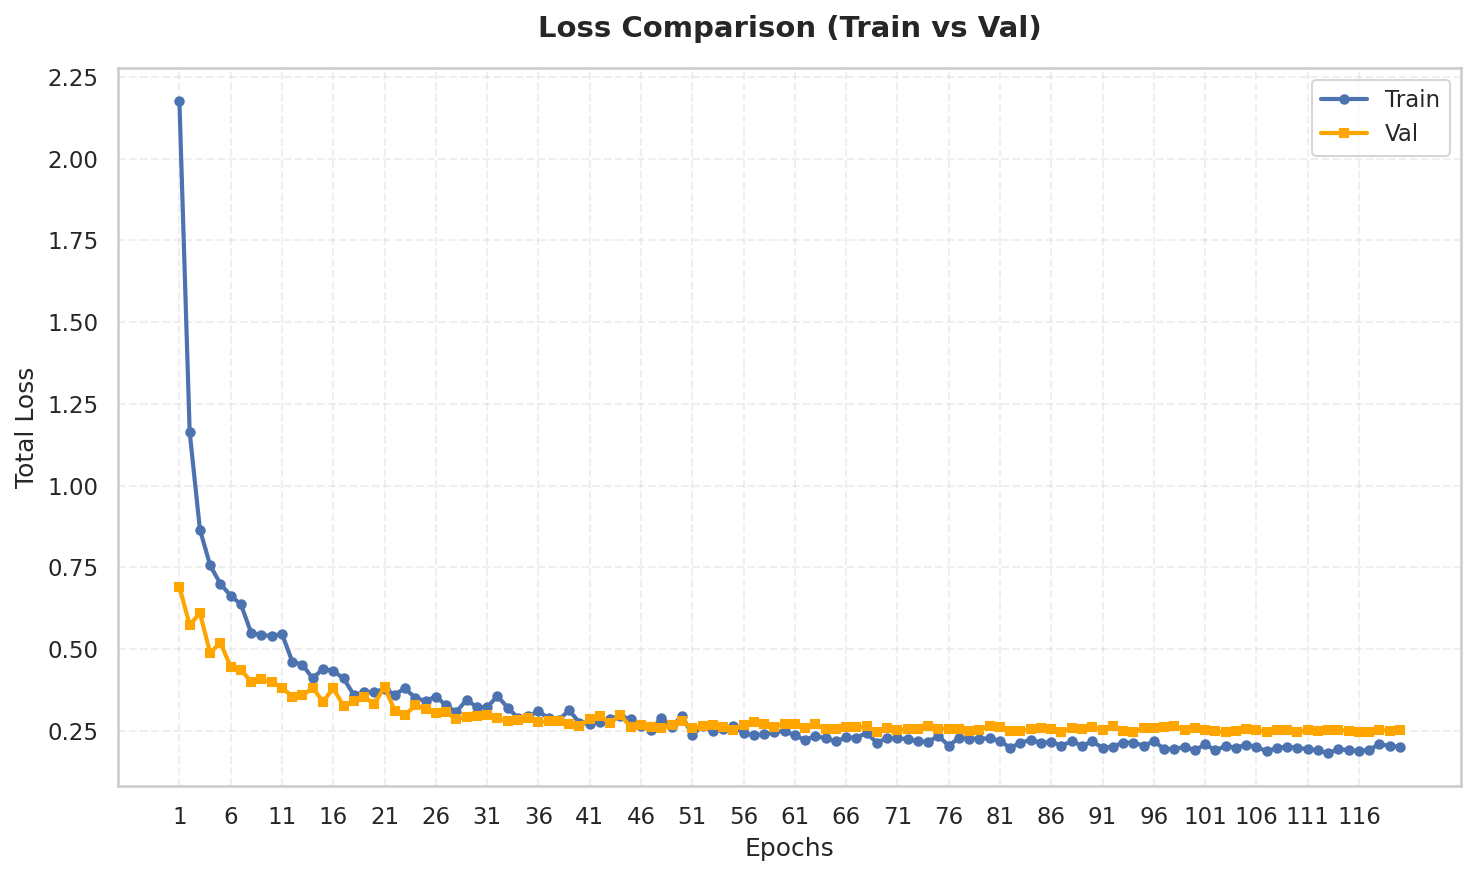

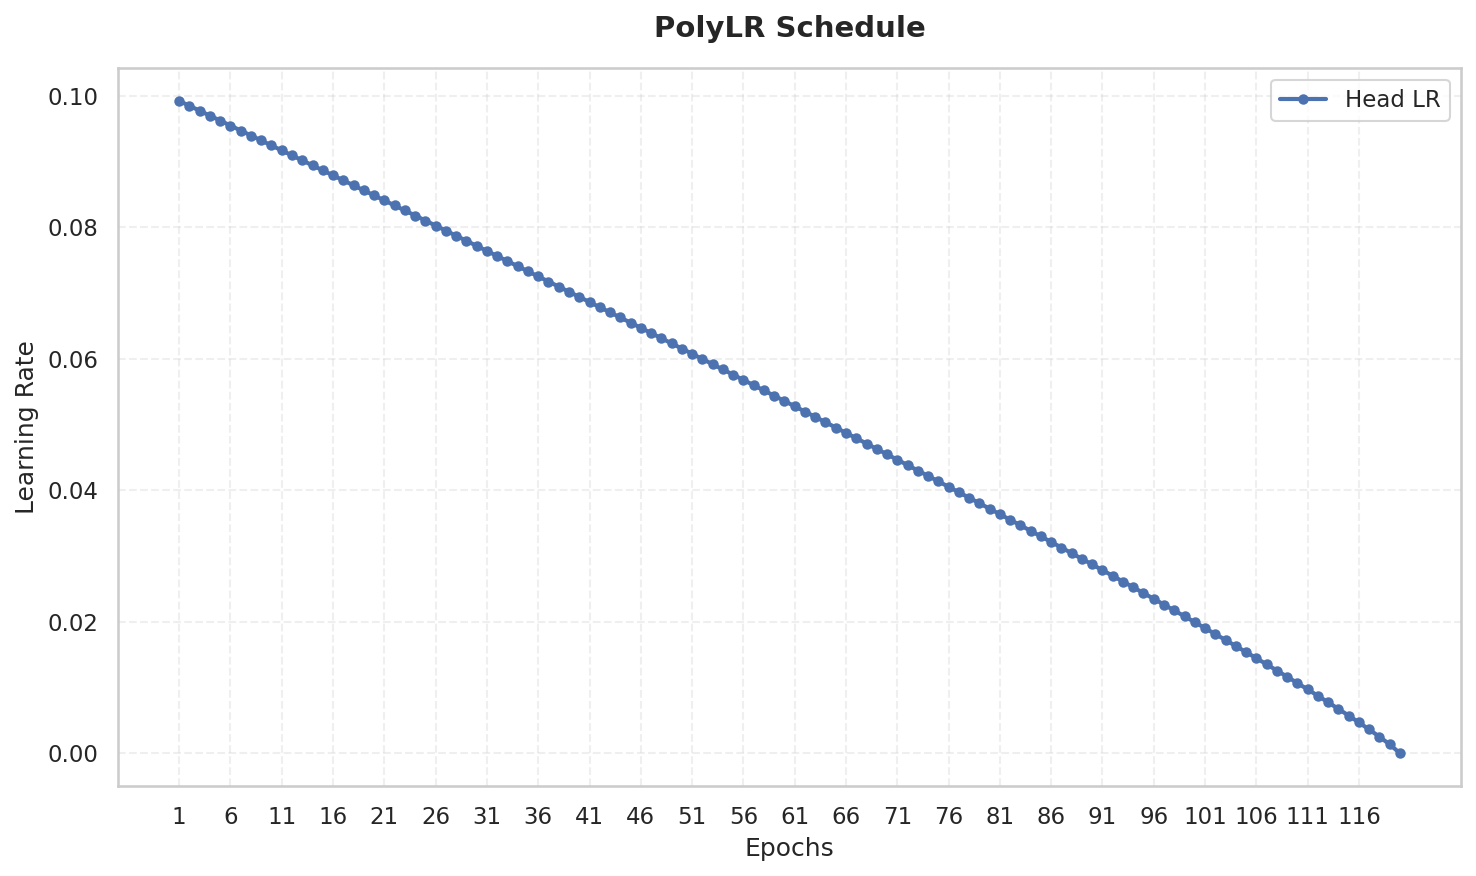

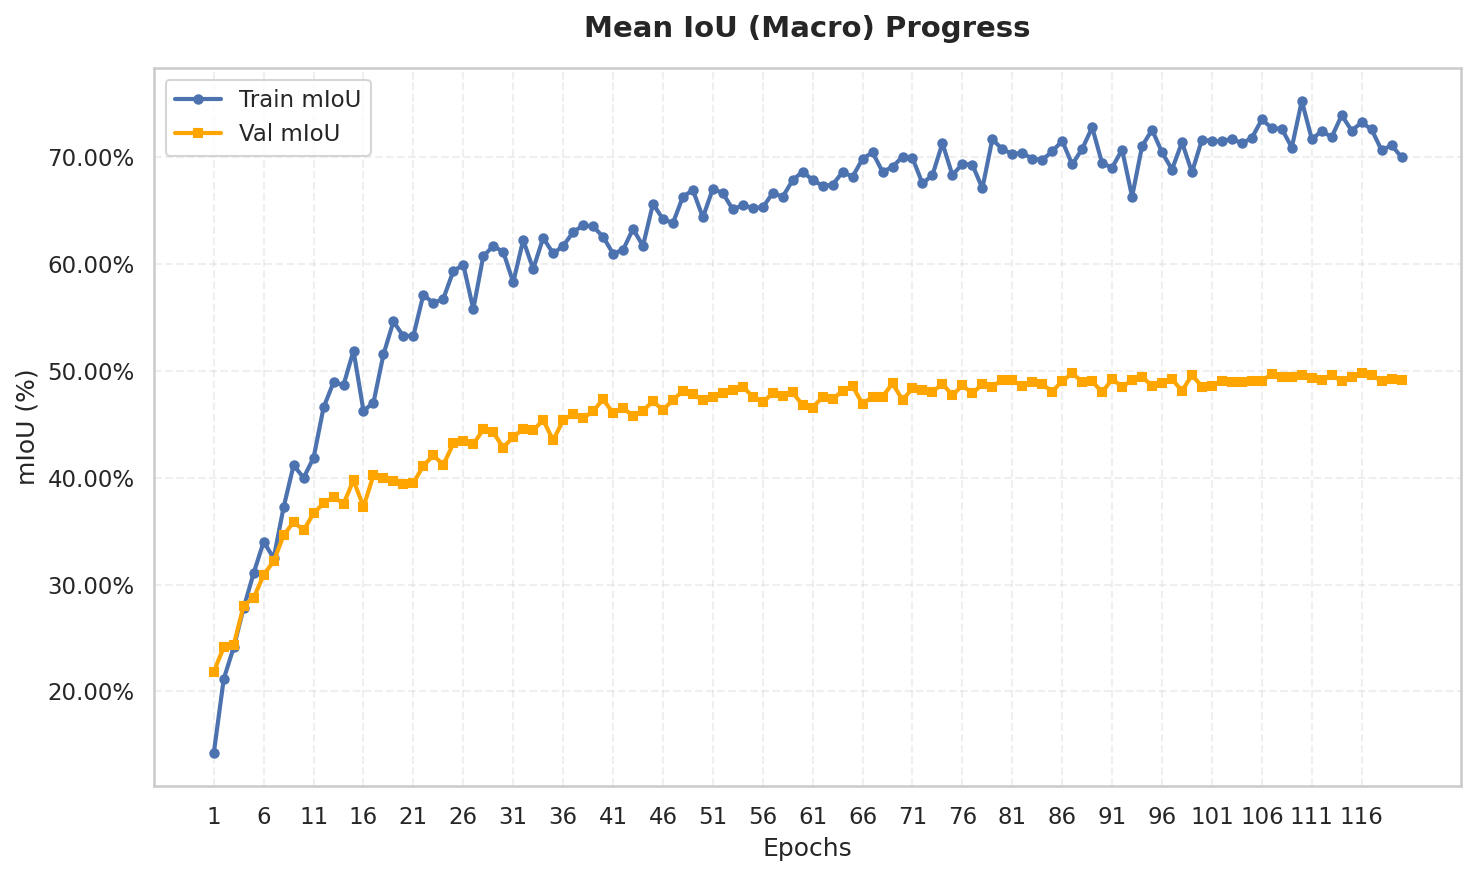

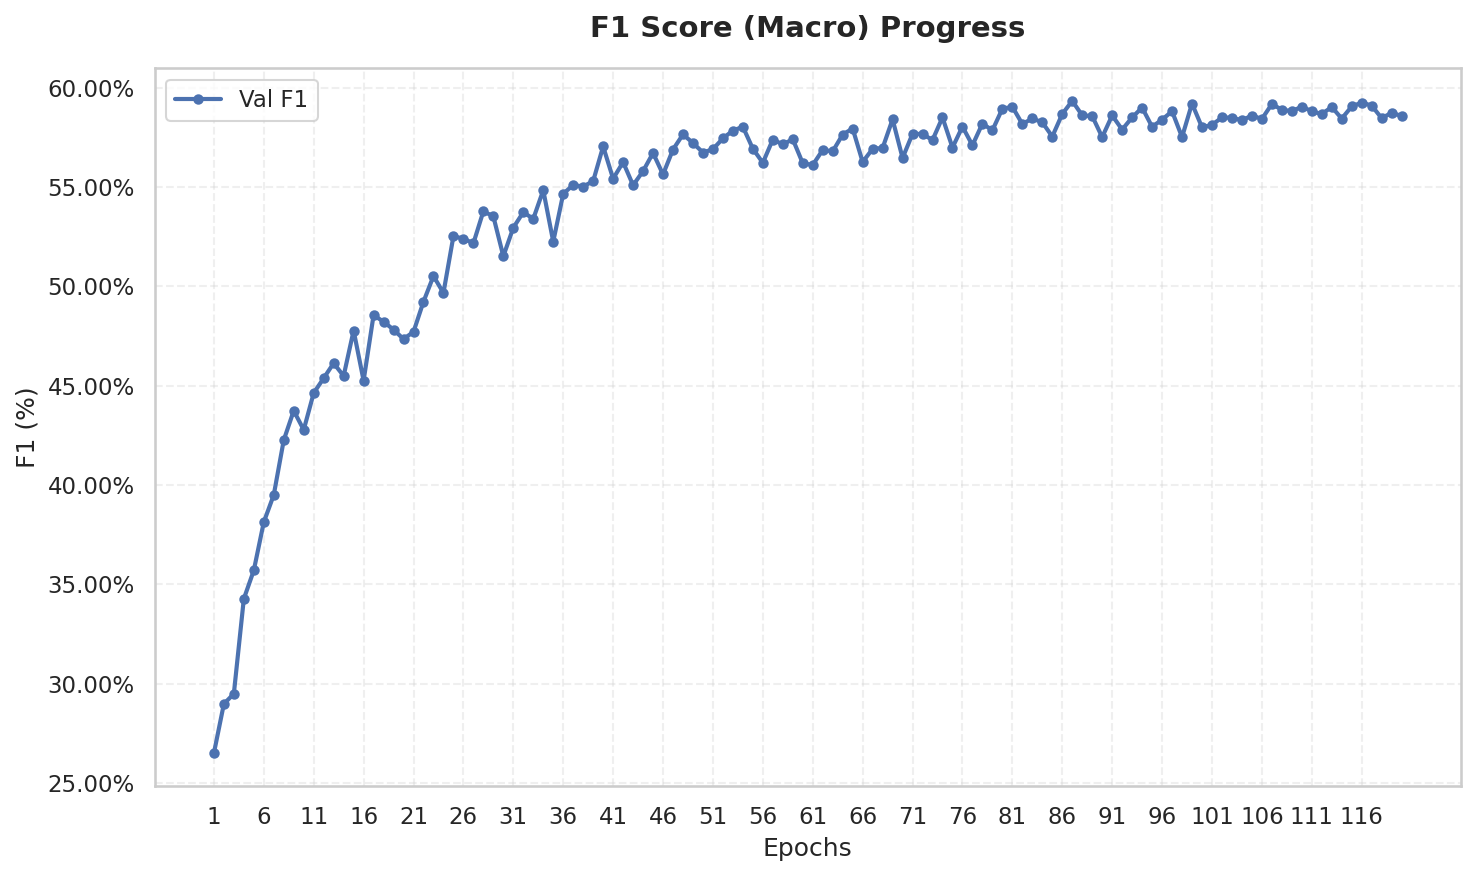

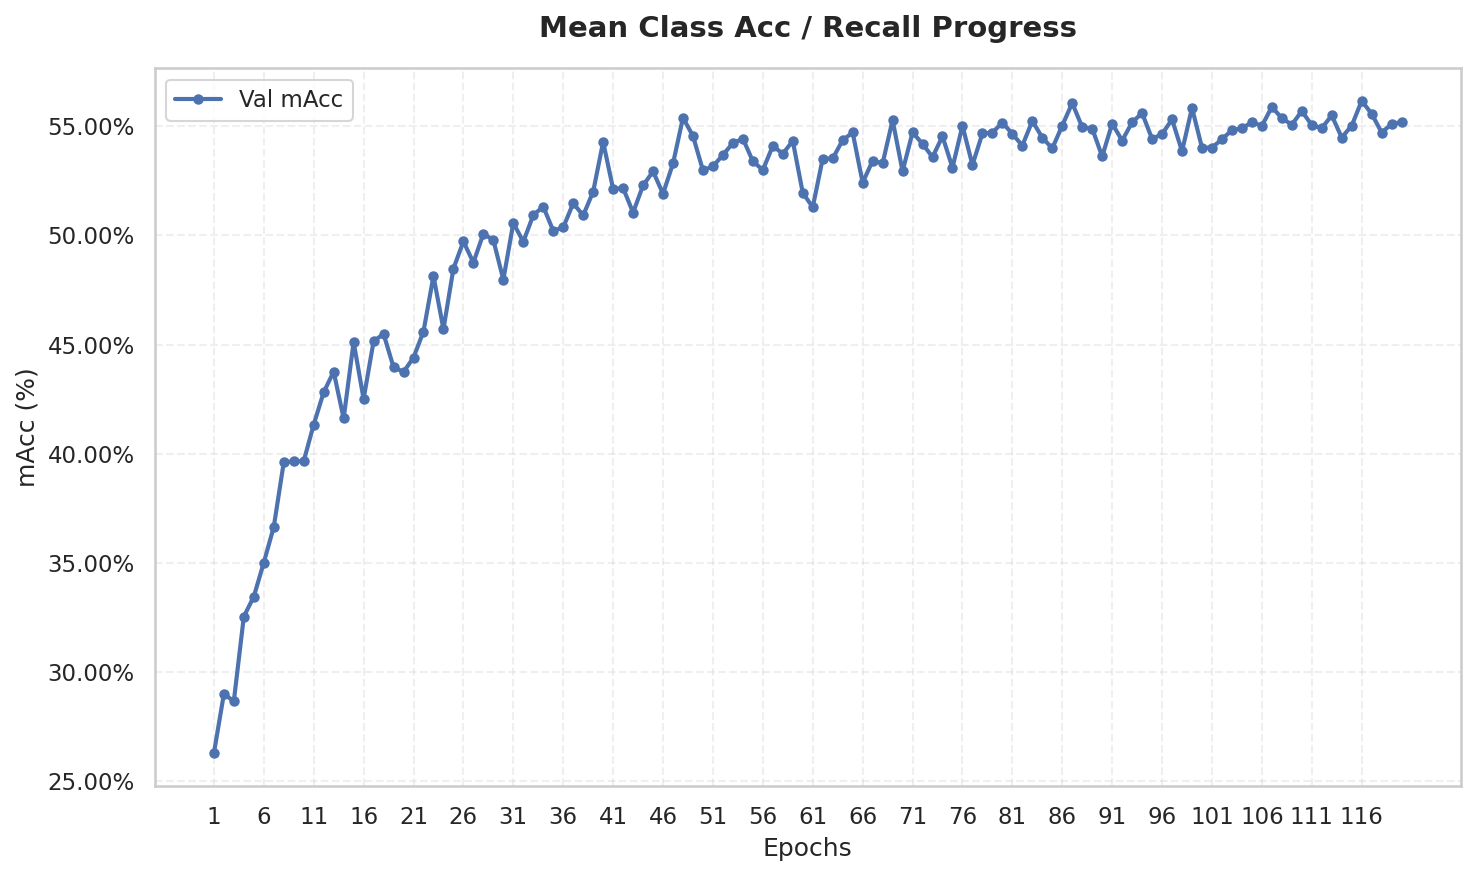

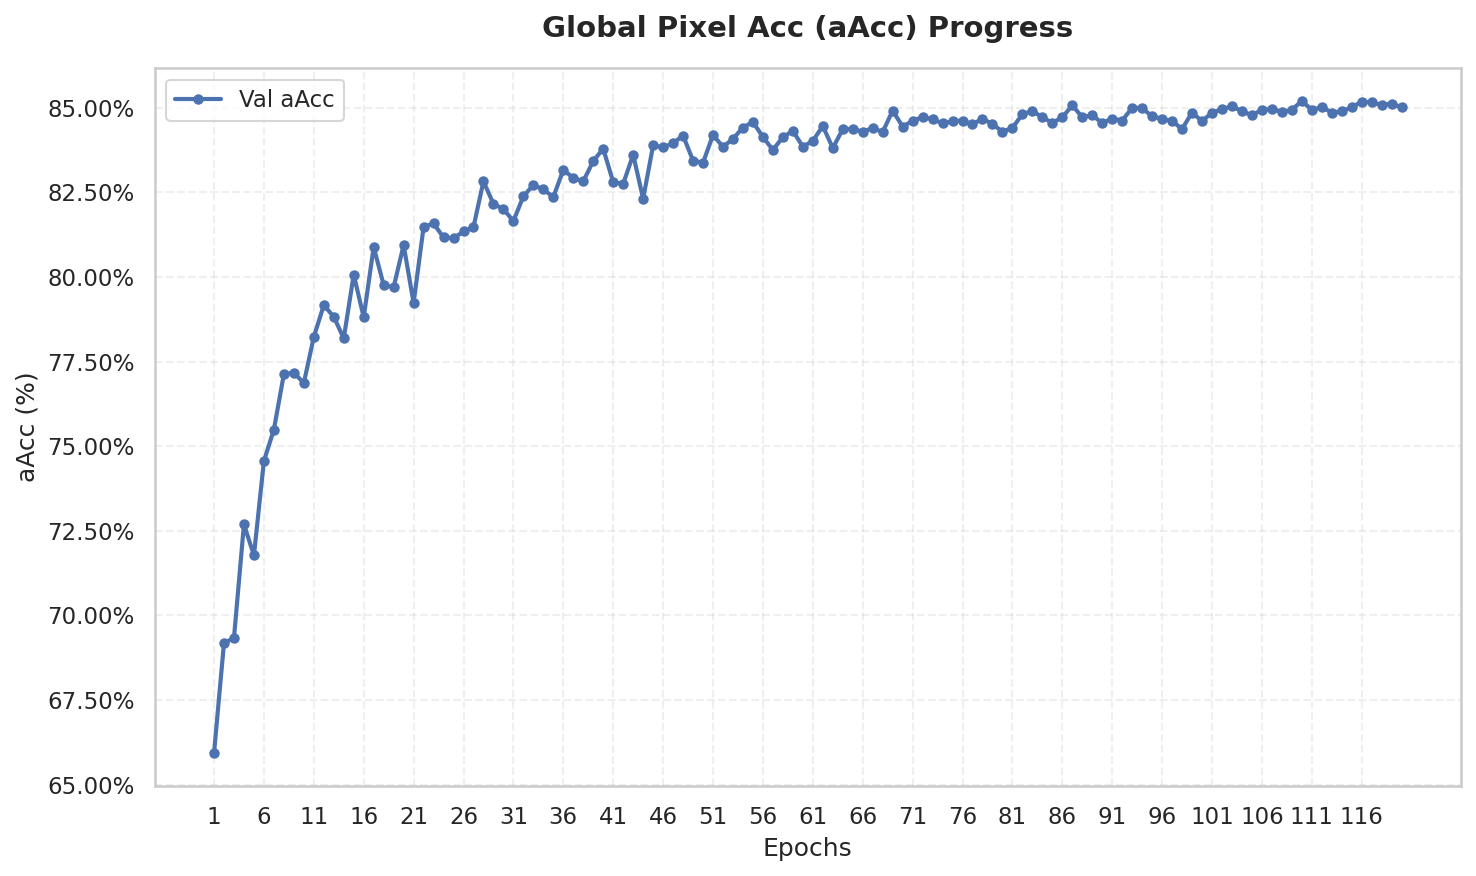

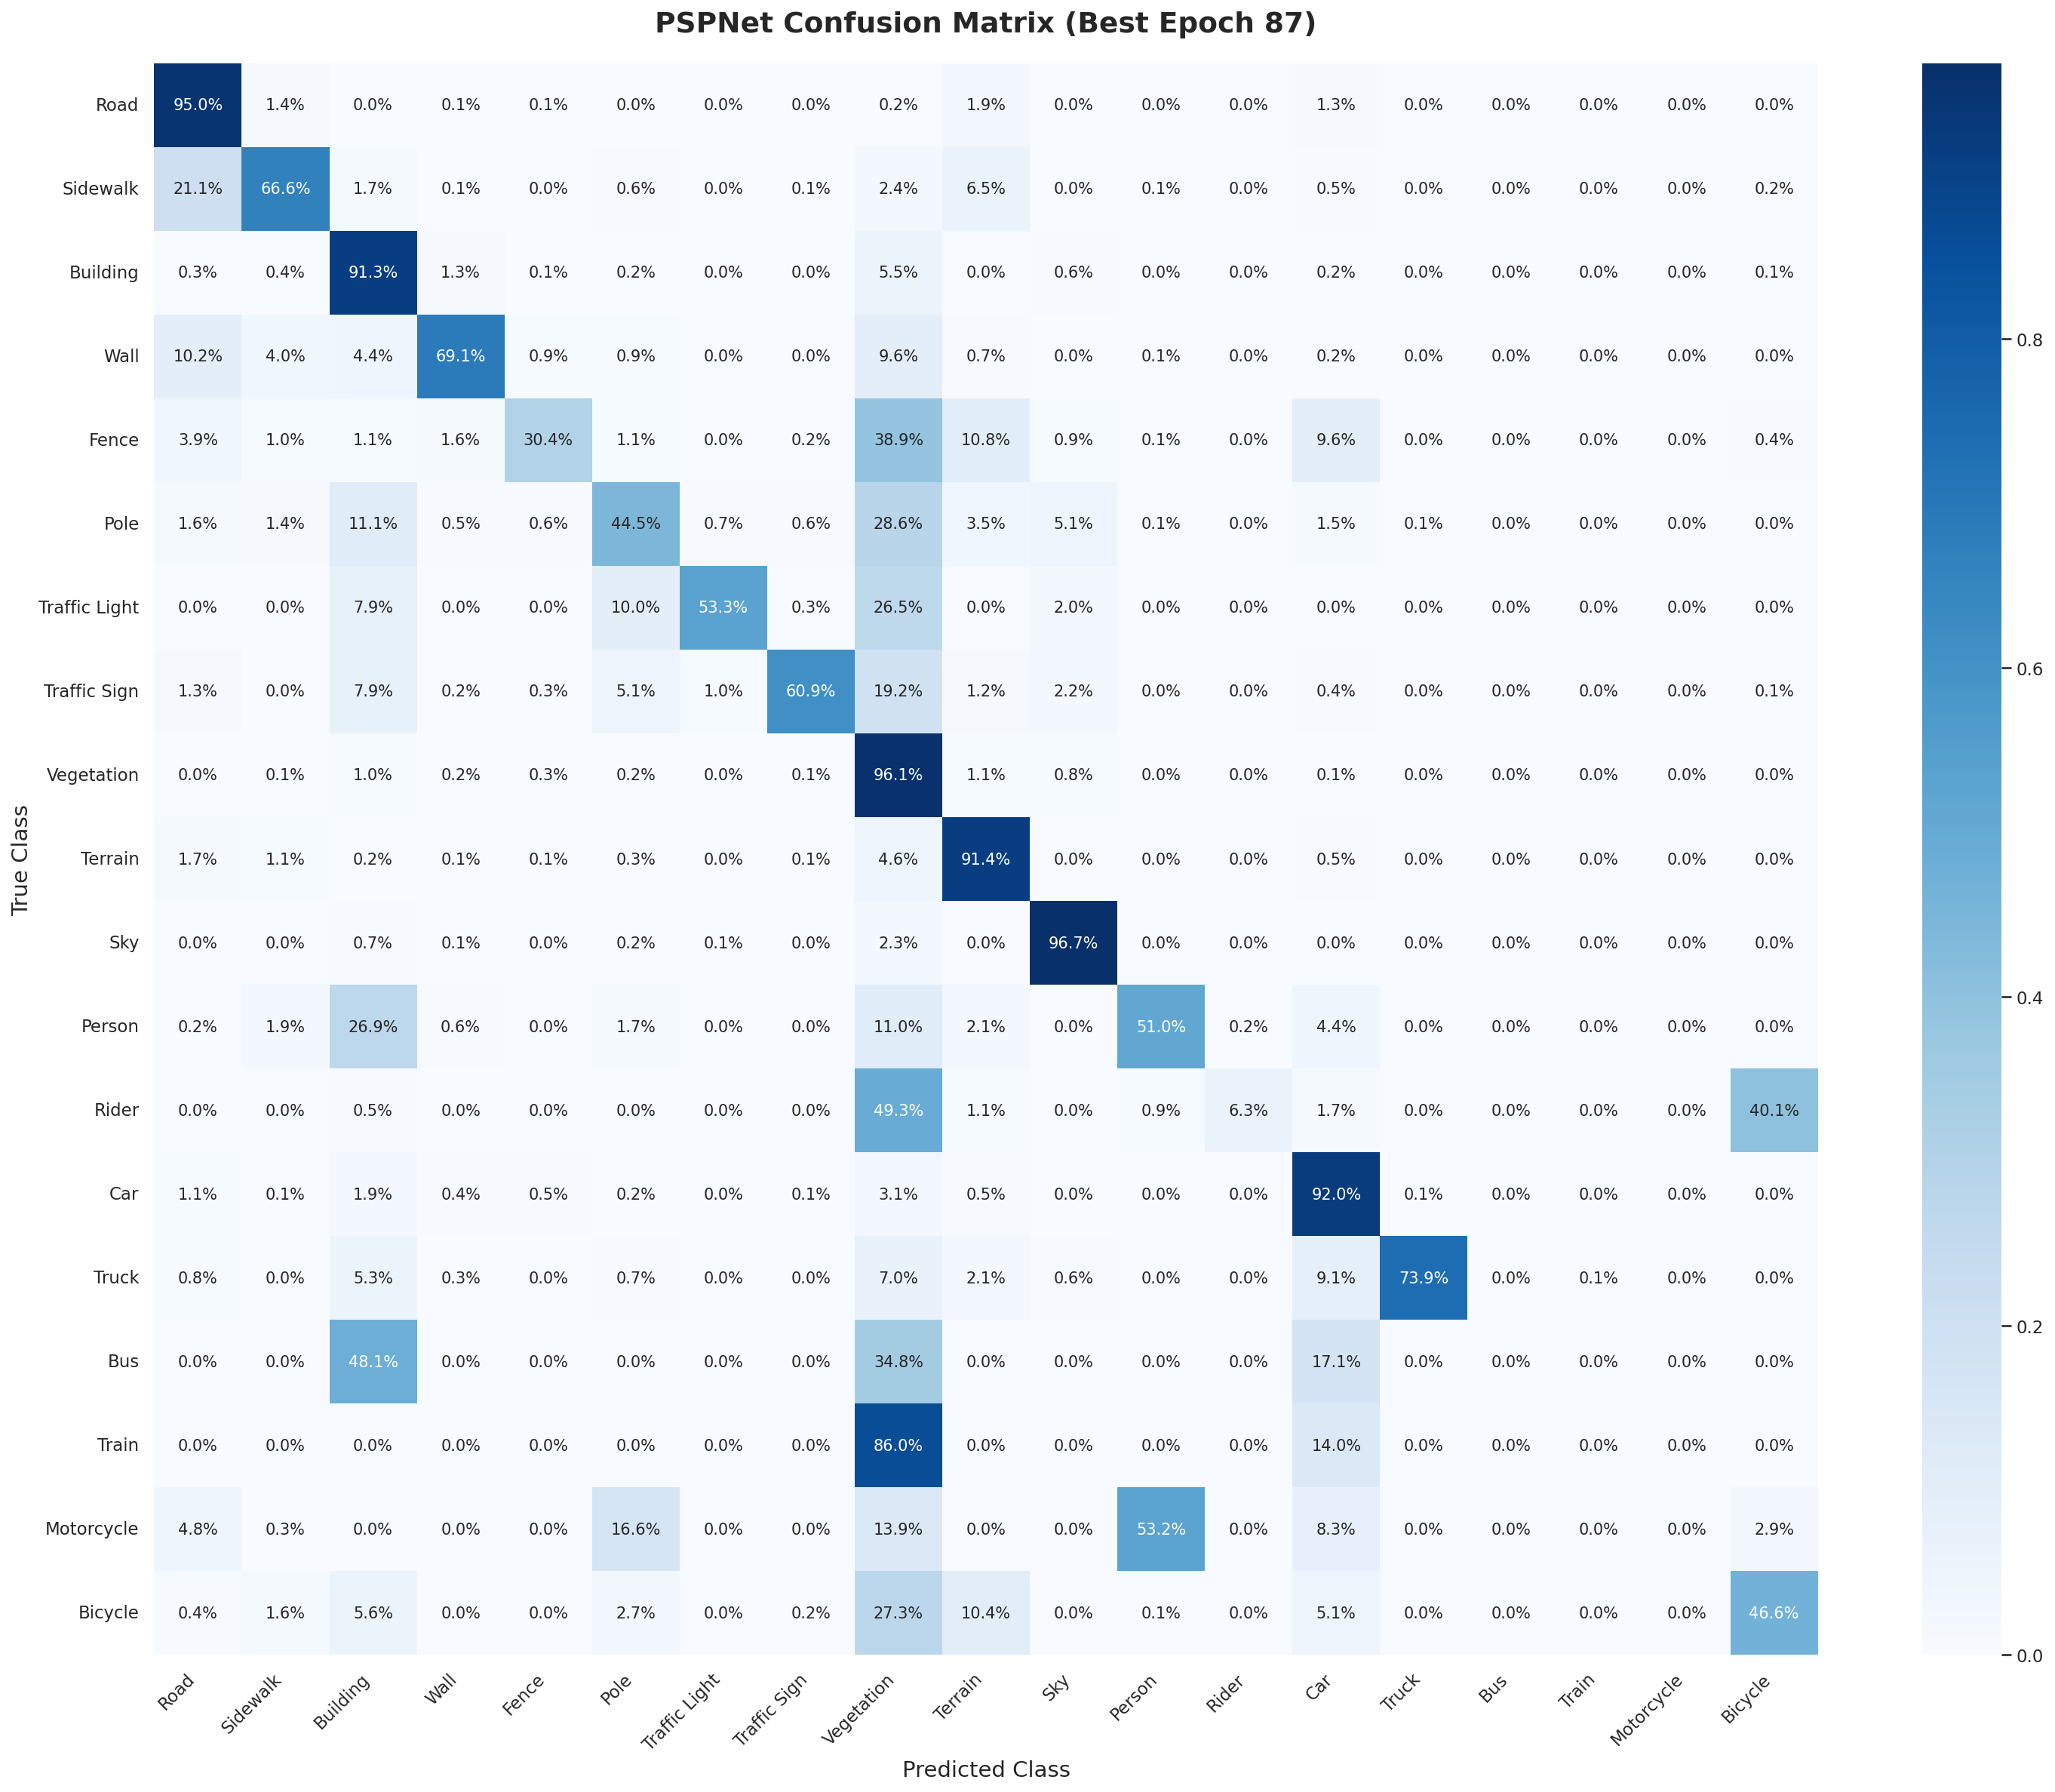


-------------------------------------------------------------------------------------
Architecture: PSPNet (ResNet101 Backbone + Pyramid Pooling Module)
Loss Config: Deep Supervision (Main + Aux Cross-Entropy)
Total Parameters:      67,948,390  (67.95 M)
Trainable Parameters:  67,948,390  (67.95 M)
-------------------------------------------------------------------------------------
SUCCESS: All artifacts and graphs routed to:
/home/hrusikesh-nishank/Pictures/PSPNet_kitti/Results_Export_PSPNet_kitti

FINAL RESULTS (PSPNet Architecture)
Best Validation mIoU (Macro):     49.75% (Epoch 87)
Best Validation Mean Acc (mAcc):  56.06%
Best Validation Pixel Acc (aAcc): 85.07%
Final Epoch Pixel Acc (aAcc):     85.01%
Final Epoch Mean Acc (mAcc):      55.20%
Final Epoch F1-Score (Macro):     58.58%
Total Training Time:              1:23:45
-------------------------------------------------------------------------------------
CLASS NAME         | IoU (%)      | F1-Score (%)   | Precision (%)  | Re

In [8]:
# ============================================================
# STEP 6: EXPORT RESULTS, PLOTS, CONFUSION MATRIX, FINAL SUMMARY
# Target Architecture: PSPNet (ResNet101 Backbone + Pyramid Pooling Module)
# Target Dataset: KITTI
# Optimized for: Automated Matrix Reconstruction, Class-Wise Parsing, 
# Percentage Matrices, Continuous Metric Plotting with Inline Display
# ============================================================

import os
import json
from pathlib import Path
from datetime import timedelta

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from tqdm import tqdm
import torch.nn.functional as F

# Ensure inline rendering for Jupyter/Colab
%matplotlib inline

# ------------------------------------------------------------
# SAFETY CHECKS & PATH INHERITANCE
# ------------------------------------------------------------
required_globals = [
    "history", "model", "CLASS_NAMES", "CLASSES",
    "CHECKPOINT_DIR", "best_record", "DEVICE"
]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(f"Missing required variables from previous steps: {missing}")

IGNORE_INDEX = globals().get("IGNORE_INDEX", 255)
FINAL_SAVE_DIR = globals().get("FINAL_SAVE_DIR", Path("/home/hrusikesh-nishank/Pictures/PSPNet_kitti/Results_Export_PSPNet_kitti"))
FINAL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"[*] Final export directory validated: {FINAL_SAVE_DIR.resolve()}\n")

# ------------------------------------------------------------
# AUTOMATED MATRIX RECOVERY PROTOCOL (CRASH PROOF)
# ------------------------------------------------------------
BEST_CONF_MATRIX = globals().get("best_conf_matrix", globals().get("val_conf_matrix", None))
best_metrics = globals().get("best_metrics", None)

if (BEST_CONF_MATRIX is None or best_metrics is None) and "val_loader" in globals() and "model" in globals():
    print("[!] Confusion matrix missing from RAM. Reconstructing from Best Checkpoint...")
    best_ckpt_path = os.path.join(CHECKPOINT_DIR, "best_model_pspnet_kitti.pt")
    
    if os.path.exists(best_ckpt_path):
        ckpt = torch.load(best_ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt["model_state_dict"])
        model.eval()
        
        reconstructed_cm = np.zeros((CLASSES, CLASSES), dtype=np.int64)
        
        def _fast_confusion_matrix(y_true, y_pred, num_classes):
            idx = num_classes * y_true + y_pred
            return np.bincount(idx, minlength=num_classes**2).reshape(num_classes, num_classes)
        
        USE_AMP = torch.cuda.is_available()
        pbar = tqdm(val_loader, total=len(val_loader), desc="Reconstructing Metrics (TTA)", leave=False)
        
        with torch.no_grad():
            for images, masks in pbar:
                images = images.to(DEVICE, non_blocking=True)
                masks = masks.to(DEVICE, non_blocking=True)
                _, _, val_h, val_w = images.shape
                
                scales = [0.75, 1.0, 1.25]
                final_logits = torch.zeros((images.shape[0], CLASSES, val_h, val_w), device=DEVICE, dtype=torch.float32)
                
                for scale in scales:
                    sH, sW = (int(val_h * scale) // 32) * 32, (int(val_w * scale) // 32) * 32 
                    scaled_img = F.interpolate(images, size=(sH, sW), mode='bilinear', align_corners=False)
                    
                    with torch.autocast(device_type="cuda", enabled=USE_AMP):
                        logits = model(scaled_img)
                        logits_up = F.interpolate(logits, size=(val_h, val_w), mode="bilinear", align_corners=False)
                        final_logits += logits_up.float()
                        
                        flip_logits = model(torch.flip(scaled_img, dims=[3]))
                        flip_logits_up = F.interpolate(flip_logits, size=(val_h, val_w), mode="bilinear", align_corners=False)
                        final_logits += torch.flip(flip_logits_up, dims=[3]).float()
                        
                semantic_logits = final_logits / (len(scales) * 2)
                
                preds = torch.argmax(semantic_logits, dim=1).cpu().numpy().astype(np.int64)
                targets_np = masks.cpu().numpy().astype(np.int64)
                
                valid = (targets_np != IGNORE_INDEX)
                if valid.any():
                    reconstructed_cm += _fast_confusion_matrix(targets_np[valid], preds[valid], CLASSES)
                    
        BEST_CONF_MATRIX = reconstructed_cm
        
        tp = np.diag(BEST_CONF_MATRIX)
        fp = BEST_CONF_MATRIX.sum(axis=0) - tp
        fn = BEST_CONF_MATRIX.sum(axis=1) - tp
        
        precision_class = tp / np.maximum(tp + fp, 1)
        recall_class = tp / np.maximum(tp + fn, 1)
        iou_class = tp / np.maximum(tp + fp + fn, 1)
        f1_class = 2 * (precision_class * recall_class) / np.maximum(precision_class + recall_class, 1e-8)

        total_tp, total_fp, total_fn = tp.sum(), fp.sum(), fn.sum()
        
        best_metrics = {
            "mIoU_Macro": float(np.nanmean(iou_class)),
            "Precision_Macro": float(np.nanmean(precision_class)),
            "Recall_Macro": float(np.nanmean(recall_class)),
            "F1_Macro": float(np.nanmean(f1_class)),
            "mIoU_Micro": float(total_tp / max(total_tp + total_fp + total_fn, 1)),
            "Precision_Micro": float(total_tp / max(total_tp + total_fp, 1)),
            "Recall_Micro": float(total_tp / max(total_tp + total_fn, 1))
        }
        
        print("[*] Reconstruction Complete! Restoring class-wise scores.")
    else:
        print("[!] Could not locate best checkpoint on disk. Class-wise metrics will remain empty.")

# ------------------------------------------------------------
# BUILD MAIN DATAFRAME
# ------------------------------------------------------------
num_epochs = len(history.get("epoch", []))

def get_hist_col(key, fallback_key=None):
    col = history.get(key, [])
    if len(col) == num_epochs: return col
    if fallback_key and len(history.get(fallback_key, [])) == num_epochs: return history[fallback_key]
    if len(col) > 0:
        return col + [np.nan] * (num_epochs - len(col)) if len(col) < num_epochs else col[:num_epochs]
    return [np.nan] * num_epochs

df = pd.DataFrame({
    "Epoch": get_hist_col("epoch"),
    "Train_Total_Loss": get_hist_col("train_total_loss"),
    "Train_mIoU": get_hist_col("train_mIoU_Macro", fallback_key="train_miou"),
    "Val_Total_Loss": get_hist_col("val_total_loss"),
    "Val_mIoU": get_hist_col("val_mIoU_Macro", fallback_key="val_miou"),
    "Val_F1_Macro": get_hist_col("val_F1_Macro"),
    "Val_Precision_Macro": get_hist_col("val_Precision_Macro"),
    "Val_Recall_Macro": get_hist_col("val_Recall_Macro", fallback_key="val_macc"),
    "Val_Micro_mIoU": get_hist_col("val_mIoU_Micro", fallback_key="val_aacc"),
    "Learning_Rate": get_hist_col("learning_rate"),
    "Epoch_Time_sec": get_hist_col("epoch_time_sec"),
})

total_training_time_sec = float(df["Epoch_Time_sec"].sum()) if not df["Epoch_Time_sec"].isna().all() else 0.0
total_time_str = str(timedelta(seconds=int(total_training_time_sec)))
df["Total_Training_Session_Time"] = total_time_str

# ------------------------------------------------------------
# PREPARE EXHAUSTIVE CLASS-WISE DATA
# ------------------------------------------------------------
class_wise_data = []
if BEST_CONF_MATRIX is not None:
    tp = np.diag(BEST_CONF_MATRIX)
    fp = BEST_CONF_MATRIX.sum(axis=0) - tp
    fn = BEST_CONF_MATRIX.sum(axis=1) - tp
    
    iou_per_class = tp / np.maximum(tp + fp + fn, 1)
    precision_per_class = tp / np.maximum(tp + fp, 1)
    recall_per_class = tp / np.maximum(tp + fn, 1)
    f1_per_class = 2 * (precision_per_class * recall_per_class) / np.maximum(precision_per_class + recall_per_class, 1e-10)
    
    for i, name in enumerate(CLASS_NAMES):
        class_wise_data.append({
            "Class Name": name,
            "IoU (%)": float(iou_per_class[i] * 100),
            "F1-Score (%)": float(f1_per_class[i] * 100),
            "Precision (%)": float(precision_per_class[i] * 100),
            "Recall (%)": float(recall_per_class[i] * 100)
        })

# ------------------------------------------------------------
# EXPORT FINAL RESULTS CSV & EXCEL
# ------------------------------------------------------------
def safe_pct(val):
    if pd.isna(val) or np.isnan(val): return 0.0
    return val if val > 1.0 else val * 100.0

final_micro_miou = safe_pct(df["Val_Micro_mIoU"].iloc[-1]) 
final_mIoU = safe_pct(df["Val_mIoU"].iloc[-1])
final_mRecall = safe_pct(df["Val_Recall_Macro"].iloc[-1])  
final_mF1 = safe_pct(df["Val_F1_Macro"].iloc[-1])

best_miou = safe_pct(best_record.get("best_miou", 0.0))
best_epoch = best_record.get("best_epoch", -1)

best_mAcc = safe_pct(best_metrics.get("Recall_Macro", 0.0)) if best_metrics else 0.0
best_aAcc = safe_pct(best_metrics.get("mIoU_Micro", 0.0)) if best_metrics else 0.0
best_mF1 = safe_pct(best_metrics.get("F1_Macro", 0.0)) if best_metrics else 0.0

final_global_data = [
    {"Metric": "Best Validation mIoU (Macro)", "Value": f"{best_miou:.2f}%"},
    {"Metric": "Best Validation Mean Class Acc (mAcc)", "Value": f"{best_mAcc:.2f}%"},
    {"Metric": "Best Validation Pixel Acc (aAcc)", "Value": f"{best_aAcc:.2f}%"},
    {"Metric": "Best Validation F1 Score (Macro)", "Value": f"{best_mF1:.2f}%"},
    {"Metric": "Final Epoch Pixel Acc (aAcc)", "Value": f"{final_micro_miou:.2f}%"},
    {"Metric": "Final Epoch Mean Class Acc (mAcc)", "Value": f"{final_mRecall:.2f}%"},
    {"Metric": "Final Epoch Mean F1 Score (Macro)", "Value": f"{final_mF1:.2f}%"},
    {"Metric": "Total Training Time", "Value": total_time_str}
]
pd.DataFrame(final_global_data).to_csv(FINAL_SAVE_DIR / "finalresults_pspnet.csv", index=False)

excel_path = FINAL_SAVE_DIR / "Training_Metrics_Report_PSPNet.xlsx"
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Epoch_Metrics', index=False)
    if class_wise_data:
        pd.DataFrame(class_wise_data).to_excel(writer, sheet_name='Class_Wise_Results', index=False)

# ------------------------------------------------------------
# STANDARD SEPARATE PLOTS (INDIVIDUAL METRICS WITH PLT.SHOW)
# ------------------------------------------------------------
sns.set_style("whitegrid")

def save_separate_plot(filename, title, ylabel, train_data, val_data=None, label1="Train", label2="Val", is_percentage=False):
    plt.figure(figsize=(10, 6))
    
    epochs_range = df["Epoch"].dropna().values if not df["Epoch"].isna().all() else np.arange(1, len(train_data) + 1)
    train_clean = np.array(train_data, dtype=float)
    
    if not np.isnan(train_clean).all():
        plt.plot(epochs_range, train_clean, label=label1, lw=2, marker='o', markersize=4)
    
    if val_data is not None:
        val_clean = np.array(val_data, dtype=float)
        if not np.isnan(val_clean).all():
            plt.plot(epochs_range, val_clean, label=label2, lw=2, marker='s', markersize=4, color='orange')
            
    if is_percentage:
        plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))

    if len(epochs_range) > 0:
        plt.xticks(np.arange(min(epochs_range), max(epochs_range) + 1, step=5))

    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig(FINAL_SAVE_DIR / f"{filename}.png", dpi=600, bbox_inches='tight')
    plt.show()  # Renders the plot inline inside the notebook
    plt.close()

# Extract Data
train_loss = df["Train_Total_Loss"].tolist()
val_loss = df["Val_Total_Loss"].tolist()
train_miou = df["Train_mIoU"].tolist()
val_miou = df["Val_mIoU"].tolist()
val_f1 = df["Val_F1_Macro"].tolist()
val_recall = df["Val_Recall_Macro"].tolist()
val_micro = df["Val_Micro_mIoU"].tolist()
learning_rate = df["Learning_Rate"].tolist()

# 1. Loss & Mechanics Plots
save_separate_plot("loss_comparison", "Loss Comparison (Train vs Val)", "Total Loss", train_loss, val_loss)
save_separate_plot("learning_rate_progress", "PolyLR Schedule", "Learning Rate", learning_rate, label1="Head LR")

# 2. Individual Evaluation Metric Plots
save_separate_plot("miou_progress", "Mean IoU (Macro) Progress", "mIoU (%)", train_miou, val_miou, label1="Train mIoU", label2="Val mIoU", is_percentage=True)
save_separate_plot("f1_progress", "F1 Score (Macro) Progress", "F1 (%)", val_f1, label1="Val F1", is_percentage=True)
save_separate_plot("recall_progress", "Mean Class Acc / Recall Progress", "mAcc (%)", val_recall, label1="Val mAcc", is_percentage=True)
save_separate_plot("micro_miou_progress", "Global Pixel Acc (aAcc) Progress", "aAcc (%)", val_micro, label1="Val aAcc", is_percentage=True)

# ------------------------------------------------------------
# PERCENTAGE-BASED CONFUSION MATRIX (WITH PLT.SHOW)
# ------------------------------------------------------------
if BEST_CONF_MATRIX is not None:
    plt.figure(figsize=(20, 16)) 
    
    cm_normalized = BEST_CONF_MATRIX.astype('float') / (BEST_CONF_MATRIX.sum(axis=1)[:, np.newaxis] + 1e-10)
    
    sns.heatmap(
        cm_normalized, annot=True, fmt='.1%', cmap='Blues', 
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, 
        annot_kws={"size": 10}
    ) 
    
    plt.title(f"PSPNet Confusion Matrix (Best Epoch {best_epoch})", fontsize=18, fontweight='bold', pad=20)
    plt.ylabel('True Class', fontsize=14)
    plt.xlabel('Predicted Class', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(FINAL_SAVE_DIR / "confusion_matrix_percentages.png", dpi=600, bbox_inches='tight')
    plt.show()  # Renders the confusion matrix heatmap inline
    plt.close()

# ------------------------------------------------------------
# FINAL PRINT SUMMARY
# ------------------------------------------------------------
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n" + "-"*85)
print(f"Architecture: PSPNet (ResNet101 Backbone + Pyramid Pooling Module)")
print(f"Loss Config: Deep Supervision (Main + Aux Cross-Entropy)")
print(f"Total Parameters:      {total_params:,}  ({total_params/1e6:.2f} M)")
print(f"Trainable Parameters:  {trainable_params:,}  ({trainable_params/1e6:.2f} M)")
print(f"-"*85)
print(f"SUCCESS: All artifacts and graphs routed to:\n{FINAL_SAVE_DIR.resolve()}")
print("\n" + "="*85)
print(f"FINAL RESULTS (PSPNet Architecture)")
print("="*85)
print(f"Best Validation mIoU (Macro):     {best_miou:.2f}% (Epoch {best_epoch})")
print(f"Best Validation Mean Acc (mAcc):  {best_mAcc:.2f}%")
print(f"Best Validation Pixel Acc (aAcc): {best_aAcc:.2f}%")
print(f"Final Epoch Pixel Acc (aAcc):     {final_micro_miou:.2f}%")
print(f"Final Epoch Mean Acc (mAcc):      {final_mRecall:.2f}%")
print(f"Final Epoch F1-Score (Macro):     {final_mF1:.2f}%")
print(f"Total Training Time:              {total_time_str}")
print("-" * 85)
print(f"{'CLASS NAME':<18} | {'IoU (%)':<12} | {'F1-Score (%)':<14} | {'Precision (%)':<14} | {'Recall (%)':<12}")
print("-" * 85)

if class_wise_data:
    for item in class_wise_data:
        print(f"{item['Class Name']:<18} | {item['IoU (%)']:<12.2f} | {item['F1-Score (%)']:<14.2f} | {item['Precision (%)']:<14.2f} | {item['Recall (%)']:<12.2f}")

[*] Filtered Multi-Metric Graph saved successfully to: /home/hrusikesh-nishank/Pictures/PSPNet_kitti/Results_Export_PSPNet_kitti/presentation_combined_metrics_progress.png


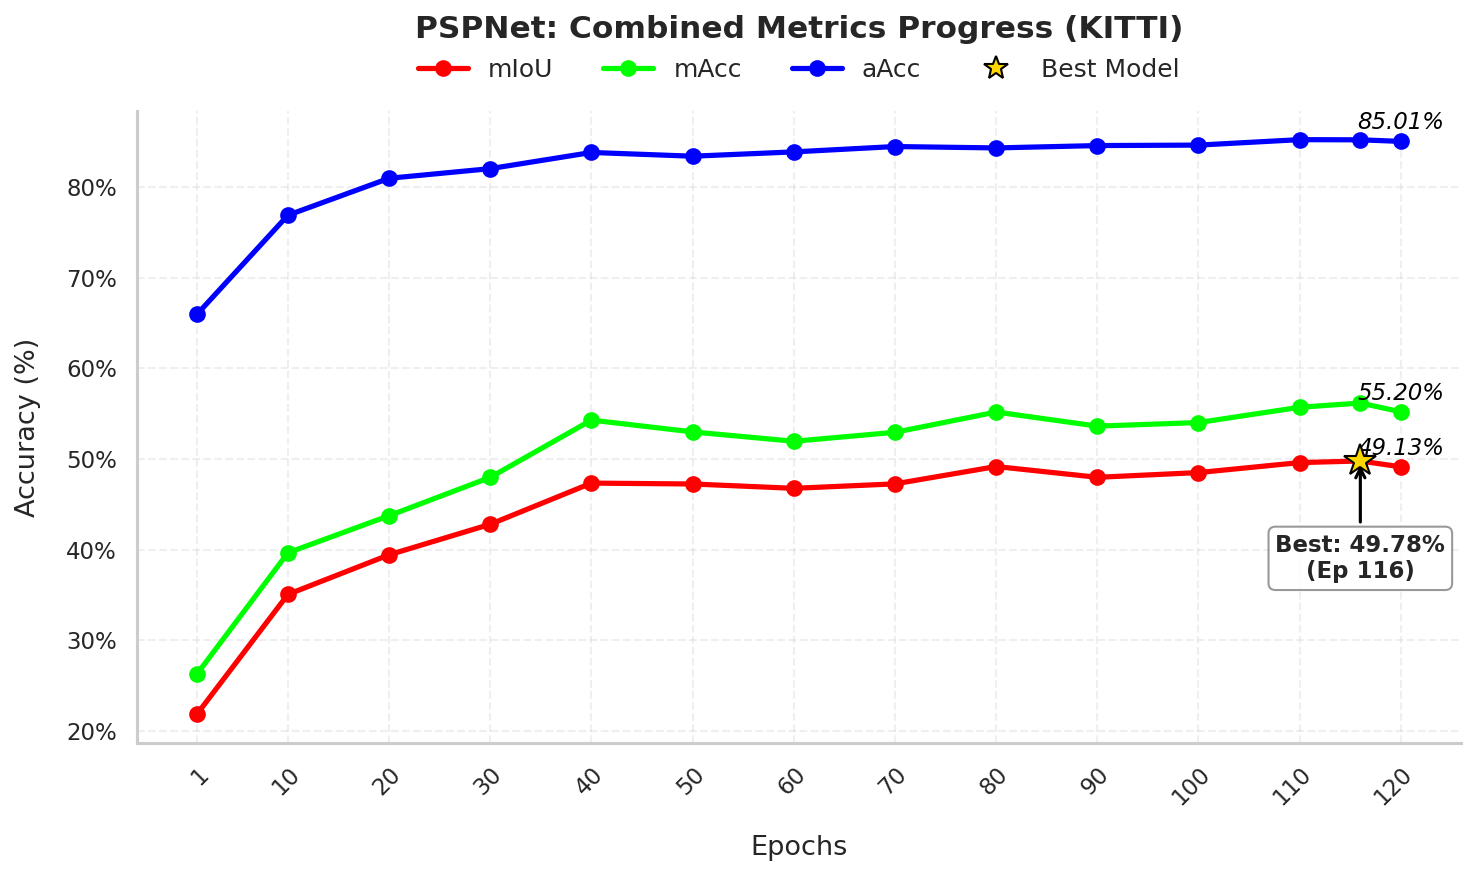

[*] Filtered PolyLR Graph saved successfully to: /home/hrusikesh-nishank/Pictures/PSPNet_kitti/Results_Export_PSPNet_kitti/presentation_learning_rate_schedule.png


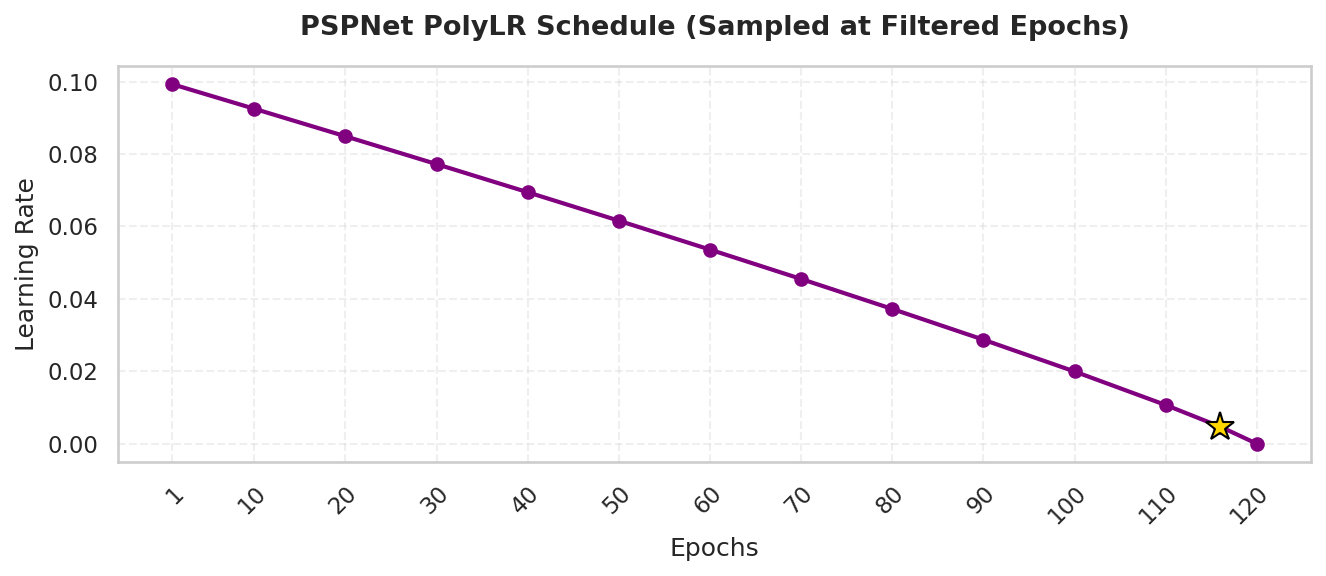

In [10]:
# ============================================================
# STEP 7: FILTERED COMBINED METRICS PLOT & LEARNING RATE
# Target Architecture: PSPNet (ResNet101 Backbone + Pyramid Pooling Module)
# Target Dataset: KITTI
# Optimized for: Clean X-Axis, Fixed Legend Overlap, Inline Display
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Ensure inline rendering for Jupyter/Colab
%matplotlib inline

# ---------------------------------------------------------------------
# 0) Safety checks
# ---------------------------------------------------------------------
assert "val_miou" in history and len(history["val_miou"]) > 0, "history['val_miou'] is empty."
assert FINAL_SAVE_DIR.exists(), "FINAL_SAVE_DIR does not exist. Run Step 6 directory setup first."

# ---------------------------------------------------------------------
# 1) Setup Plotting Data vs Axis Ticks
# ---------------------------------------------------------------------
best_miou_raw = max(history["val_miou"])
best_miou_idx = history["val_miou"].index(best_miou_raw)
best_epoch = history["epoch"][best_miou_idx]

# Values are already 0-100 scaled from Step 5.
best_miou_pct = best_miou_raw 

all_epochs = list(range(1, len(history["val_miou"]) + 1))
step = 20 if len(all_epochs) > 150 else 10

# List A: STRICTLY for the X-Axis labels (Clean sequence)
tick_epochs = [e for e in all_epochs if (e == 1) or (e % step == 0)]
if all_epochs[-1] not in tick_epochs:
    tick_epochs.append(all_epochs[-1])
tick_epochs = sorted(list(set(tick_epochs)))

# List B: For plotting the actual lines (Includes the peak epoch to connect the dot)
plot_epochs = tick_epochs.copy()
if best_epoch not in plot_epochs:
    plot_epochs.append(best_epoch)
plot_epochs = sorted(list(set(plot_epochs)))

# Extract metrics using the plot_epochs so the data aligns mathematically
indices = [e - 1 for e in plot_epochs]

miou_scores = [history["val_miou"][i] for i in indices]
macc_scores = [history["val_macc"][i] for i in indices]  
aacc_scores = [history["val_aacc"][i] for i in indices]  

# ---------------------------------------------------------------------
# 2) Plot combined metrics
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6)) # Slightly widened for a cleaner look

ax.plot(plot_epochs, miou_scores, marker="o", color='red', linewidth=2.5, label="mIoU", markersize=7)
ax.plot(plot_epochs, macc_scores, marker="o", color='lime', linewidth=2.5, label="mAcc", markersize=7)
ax.plot(plot_epochs, aacc_scores, marker="o", color='blue', linewidth=2.5, label="aAcc", markersize=7)

# Highlight the Best mIoU Point
ax.plot(best_epoch, best_miou_pct, marker="*", color="gold", markersize=16, markeredgecolor="black", zorder=5)

ax.annotate(
    f"Best: {best_miou_pct:.2f}%\n(Ep {best_epoch})", 
    xy=(best_epoch, best_miou_pct), 
    xytext=(best_epoch, best_miou_pct - 8.0), 
    ha="center", va="top", 
    fontsize=11, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5, connectionstyle="arc3")
)

ax.set_xlabel("Epochs", fontsize=13, labelpad=12)
ax.set_ylabel("Accuracy (%)", fontsize=13, labelpad=12)
ax.set_title("PSPNet: Combined Metrics Progress (KITTI)", fontsize=15, fontweight='bold', pad=35)

ax.set_xticks(tick_epochs)
ax.set_xticklabels([str(e) for e in tick_epochs]) 
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# Add percentage values to the final dots
final_x = plot_epochs[-1]
offset = 0.8

ax.text(final_x, miou_scores[-1] + offset, f"{miou_scores[-1]:.2f}%",
        ha="center", va="bottom", fontsize=11, fontstyle="italic", color="black")
ax.text(final_x, macc_scores[-1] + offset, f"{macc_scores[-1]:.2f}%",
        ha="center", va="bottom", fontsize=11, fontstyle="italic", color="black")
ax.text(final_x, aacc_scores[-1] + offset, f"{aacc_scores[-1]:.2f}%",
        ha="center", va="bottom", fontsize=11, fontstyle="italic", color="black")

import matplotlib.lines as mlines
star_legend = mlines.Line2D([], [], color='white', marker='*', markerfacecolor='gold', markeredgecolor='black', markersize=12, label='Best Model')
handles, labels = ax.get_legend_handles_labels()
handles.append(star_legend)

ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.12), ncol=4, frameon=False, fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()

combined_graph_path = FINAL_SAVE_DIR / "presentation_combined_metrics_progress.png"
plt.savefig(combined_graph_path, dpi=600, bbox_inches="tight")
print(f"[*] Filtered Multi-Metric Graph saved successfully to: {combined_graph_path}")
plt.show()  # Renders the combined progress plot inline
plt.close()

# ---------------------------------------------------------------------
# 3) Filtered LR plot at the same epochs 
# ---------------------------------------------------------------------
if "learning_rate" in history and len(history["learning_rate"]) > 0:
    lr_points = [history["learning_rate"][i] for i in indices]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(plot_epochs, lr_points, marker="o", linewidth=2.0, color='purple')
    
    best_lr = history["learning_rate"][best_miou_idx]
    ax.plot(best_epoch, best_lr, marker="*", color="gold", markersize=14, markeredgecolor="black", zorder=5)
    
    ax.set_xlabel("Epochs", fontsize=12)
    ax.set_ylabel("Learning Rate", fontsize=12)
    
    ax.set_xticks(tick_epochs)
    ax.set_xticklabels([str(e) for e in tick_epochs]) 
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.set_title("PSPNet PolyLR Schedule (Sampled at Filtered Epochs)", fontsize=13, fontweight='bold', pad=15)

    plt.tight_layout()
    lr_filtered_path = FINAL_SAVE_DIR / "presentation_learning_rate_schedule.png"
    plt.savefig(lr_filtered_path, dpi=600, bbox_inches="tight")
    print(f"[*] Filtered PolyLR Graph saved successfully to: {lr_filtered_path}")
    plt.show()  # Renders the learning rate schedule plot inline
    plt.close()
else:
    print("[!] Learning rate history not found, skipping filtered LR plot.")